# Imports and Functions

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns' ,1000)
pd.set_option('display.max_rows', 1000)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from tqdm import tqdm

import pulp as p

from os.path import join
import os

import logging
from datetime import datetime
from datetime import timedelta

from IPython.display import display, Markdown

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from xgboost import XGBRegressor


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [3]:
PATH_INT = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/02_intermediate'

In [3]:
def format_val(x):
    x_int = int(x)       # drop decimal
    s = str(x_int)[-6:]  # take last 6 digits if longer
    return "C" + s.zfill(6)

In [4]:
target = 'recovery_bulk_%_Mn'

# Reading the combined data

In [5]:
master_updated = pd.read_csv(r'F:\SMS-3\notebooks\master_20260107.csv')

In [6]:
master_updated['Charging Details_Time'] = pd.to_datetime(master_updated['Charging Details_Time'],format="%d-%m-%Y %H:%M")
master_updated['Tapping_End'] = pd.to_datetime(master_updated['Tapping_End'],format="%d-%m-%Y %H:%M" )

In [7]:
master_updated['Charging Date'] = master_updated['Charging Details_Time'].dt.date
master_updated['Charging Date'] = pd.to_datetime(master_updated['Charging Date'])

## Read fluxes chemistry, reactivity, and HM chem property data

In [8]:
flux_chem_df = pd.read_excel(r'F:\SMS-3\notebooks\fluxes_chem_properties_RCL_lookup.xlsx')

In [9]:
flux_chem_df.head()

,Date,Sample Name and Number,Flux,SiO2,CaO,MgO
0,2025-07-28,lime-11,Lime,0.84,66.64,3.6
1,2025-07-28,calcined dolo-11,Calcined Dolo,3.84,44.24,25.2
2,2025-08-04,lime-12,Lime,0.76,63.84,3.2
3,2025-08-04,calcined dolo-12,Calcined Dolo,2.80,52.64,15.6
4,2025-08-11,lime-13,Lime,3.30,61.60,5.6


In [10]:
flux_react_df = pd.read_excel(r'F:\SMS-3\notebooks\fluxes_reactivity_RCL_lookup.xlsx')

In [11]:
flux_react_df.head()

,Year,Month,Day,Fluxes_Reactivity
0,2025,April,1,70
1,2025,April,2,80
2,2025,April,3,60
3,2025,April,4,60
4,2025,April,5,70


In [18]:
hm_prop_df = pd.read_excel(r'F:\SMS-3\notebooks\SMS3_HOT_METAL_ANALYSIS.xlsx')

In [19]:
hm_prop_df.head()

,TEST_DT,SAMPLE_INDEX,SI,MN,P,S,TI
0,2025-09-12 12:22:00,SMS-3/BF-8/TOR-06,1.09,0.07,0.12,0.022,0.08
1,2025-09-12 13:02:00,BF-8/27855/TLC-1B/1220,1.18,0.07,0.09,0.024,0.08
2,2025-09-12 13:36:00,SMS-3/BF-8/TOR-01,0.90,0.06,0.11,0.030,0.07
3,2025-09-12 14:30:00,BF-8/27856/TLC-4A/1330,0.80,0.07,0.10,0.018,0.07
4,2025-09-12 14:33:00,BF-8/27856/TLC-4B/1350,0.82,0.07,0.10,0.019,0.07


In [20]:
hm_prop_df['TEST_DT'] = pd.to_datetime(hm_prop_df['TEST_DT'])

hm_prop_df = hm_prop_df[~hm_prop_df['SAMPLE_INDEX'].str.contains('STD', case=False, na=False)] # Remove rows where 'SAMPLE_NAME' contains 'STD' (case-insensitive)

hm_prop_df = hm_prop_df.sort_values(['TEST_DT']) # Sort by 'TEST_DT' in ascending order

hm_prop_df = hm_prop_df.reset_index(drop=True) # Reset index after sorting

In [21]:
hm_prop_df.columns = ['HMPROP_'+col if col!='TEST_DT' else col for col in hm_prop_df.columns]
hm_prop_df.columns

Index(['TEST_DT', 'HMPROP_SAMPLE_INDEX', 'HMPROP_SI', 'HMPROP_MN', 'HMPROP_P',
       'HMPROP_S', 'HMPROP_TI'],
      dtype='str')

In [22]:
hm_prop_df.head()

,TEST_DT,HMPROP_SAMPLE_INDEX,HMPROP_SI,HMPROP_MN,HMPROP_P,HMPROP_S,HMPROP_TI
0,2025-09-12 12:22:00,SMS-3/BF-8/TOR-06,1.09,0.07,0.12,0.022,0.08
1,2025-09-12 13:02:00,BF-8/27855/TLC-1B/1220,1.18,0.07,0.09,0.024,0.08
2,2025-09-12 13:36:00,SMS-3/BF-8/TOR-01,0.90,0.06,0.11,0.030,0.07
3,2025-09-12 14:30:00,BF-8/27856/TLC-4A/1330,0.80,0.07,0.10,0.018,0.07
4,2025-09-12 14:33:00,BF-8/27856/TLC-4B/1350,0.82,0.07,0.10,0.019,0.07


In [23]:
month_to_number = { 'January':1, 'February':2, 'March':3, 'April':4,
                    'May':5, 'June':6, 'July':7, 'August':8,
                    'September':9, 'October':10, 'November':11, 'December':12 }

# hm_prop_df['Date'] = pd.to_datetime({
#     'year': 2025,
#     'month': hm_prop_df['Month'].map(month_to_number),
#     'day': hm_prop_df['Day']
# })

flux_react_df['Date'] = pd.to_datetime({
    'year': 2025,
    'month': flux_react_df['Month'].map(month_to_number),
    'day': flux_react_df['Day']
})  # Assuming current year for the 'Date' column in flux_react_df


In [24]:
flux_react_df.head()

,Year,Month,Day,Fluxes_Reactivity,Date
0,2025,April,1,70,2025-04-01
1,2025,April,2,80,2025-04-02
2,2025,April,3,60,2025-04-03
3,2025,April,4,60,2025-04-04
4,2025,April,5,70,2025-04-05


In [25]:
flux_chem_df.head()

,Date,Sample Name and Number,Flux,SiO2,CaO,MgO
0,2025-07-28,lime-11,Lime,0.84,66.64,3.6
1,2025-07-28,calcined dolo-11,Calcined Dolo,3.84,44.24,25.2
2,2025-08-04,lime-12,Lime,0.76,63.84,3.2
3,2025-08-04,calcined dolo-12,Calcined Dolo,2.80,52.64,15.6
4,2025-08-11,lime-13,Lime,3.30,61.60,5.6


In [26]:
flux_chem_lime_df = flux_chem_df[flux_chem_df['Flux']=='Lime'].copy()
flux_chem_lime_df.columns = ['LimeProp_'+col if col!='Date' else col for col in flux_chem_lime_df]
flux_chem_lime_df = flux_chem_lime_df[['Date', 'LimeProp_SiO2', 'LimeProp_CaO', 'LimeProp_MgO']].copy()
flux_chem_lime_df.head()

,Date,LimeProp_SiO2,LimeProp_CaO,LimeProp_MgO
0,2025-07-28,0.84,66.64,3.6
2,2025-08-04,0.76,63.84,3.2
4,2025-08-11,3.30,61.60,5.6
6,2025-08-18,0.98,63.84,0.4
8,2025-08-28,1.26,71.40,1.4


In [27]:
flux_chem_dolo_df = flux_chem_df[flux_chem_df['Flux']!='Lime'].copy()
flux_chem_dolo_df.columns = ['DoloProp_'+col if col!='Date' else col for col in flux_chem_dolo_df]
flux_chem_dolo_df = flux_chem_dolo_df[['Date', 'DoloProp_SiO2', 'DoloProp_CaO', 'DoloProp_MgO']].copy()
flux_chem_dolo_df.head()

,Date,DoloProp_SiO2,DoloProp_CaO,DoloProp_MgO
1,2025-07-28,3.84,44.24,25.2
3,2025-08-04,2.80,52.64,15.6
5,2025-08-11,6.44,56.56,14.4
7,2025-08-18,3.08,56.00,13.2
9,2025-08-28,4.60,48.72,25.2


In [28]:
master_updated['Charging Date'] = pd.to_datetime(
    master_updated['Charging Date']
).astype('datetime64[ns]')

flux_chem_dolo_df['Date'] = pd.to_datetime(
    flux_chem_dolo_df['Date']
).astype('datetime64[ns]')

In [29]:
flux_chem_lime_df['Date'] = pd.to_datetime(
    flux_chem_lime_df['Date']
).astype('datetime64[ns]')

flux_react_df['Date'] = pd.to_datetime(
    flux_react_df['Date']
).astype('datetime64[ns]')

hm_prop_df['TEST_DT'] = pd.to_datetime(
    hm_prop_df['TEST_DT']
).astype('datetime64[ns]')


In [30]:
flux_chem_lime_df.dtypes

Date             datetime64[ns]
LimeProp_SiO2           float64
LimeProp_CaO            float64
LimeProp_MgO            float64
dtype: object

In [31]:
master_updated['Charging Date'].dtypes, flux_chem_dolo_df.dtypes

(dtype('<M8[ns]'),
 Date             datetime64[ns]
 DoloProp_SiO2           float64
 DoloProp_CaO            float64
 DoloProp_MgO            float64
 dtype: object)

In [32]:
flux_react_df = flux_react_df.sort_values('Date')

master_updated = master_updated.sort_values('Charging Date')


In [33]:
def safe_merge_asof(left, right, left_on, right_on, direction, right_suffix):
    # Make sure no duplicate right column will cause issues
    r = right.rename(columns={right_on: f'{right_on}_{right_suffix}'})
    res = pd.merge_asof(
        left,
        r,
        left_on=left_on,
        right_on=f'{right_on}_{right_suffix}',
        direction=direction
    )
    return res

master_updated = safe_merge_asof(master_updated, flux_chem_dolo_df, 'Charging Date', 'Date', 'forward', 'flux_dolo')
master_updated = safe_merge_asof(master_updated, flux_chem_lime_df, 'Charging Date', 'Date', 'forward', 'flux_lime')
master_updated = safe_merge_asof(master_updated, flux_react_df[['Date', 'Fluxes_Reactivity']], 'Charging Date', 'Date', 'forward', 'flux_react')
master_updated = safe_merge_asof(master_updated, hm_prop_df, 'Charging Date', 'TEST_DT', 'forward', 'hm_prop')

In [34]:
master_updated.head()

,_x,Heat \nNo.,CN,Plan Details_THK,Plan Details_WTH,Plan Details_LTH,Plan Details_CC,Plan Details_Grade,Charging Details_No,Charging Details_L/D,Charging Details_Condition,Charging Details_HM Wt,Charging Details_Time,Charging Details_Ch.Wt,Mixer Analysis_Si,Mixer Analysis_Mn,Mixer Analysis_P,Mixer Analysis_S,Return Heat Details_No,Return Heat Details_T,Return Heat Details_Wt,Tapping_Start,Tapping_End,Tapping_L/D,Tap.Temp_Min,Tap.Temp_Aim,Tap.Temp_Max,Blow Details_Start,Blow Details_End,Blow Details_Oxygen,Bath Details_Temp.,Bath Details_Time,Life_T/Hole,Life_Lance,Life_CN,CREATED BY,HEATNO,REHEAT_NO,BSP_HEATNO,BSP_REHEAT_NO,CONVERTOR_ID,LINING_LIFE,TAPPING_DATE,PROD_DATE,HEAT_YEAR,LANCE,NO_OF_BLOWS,BLOW_START_1,BLOW_END,BLOW_END_1,BLOW_START_2,BLOW_END_2,BLOW_START_3,BLOW_END_3,BLOW_START_4,BLOW_END_4,BLOW_START_5,BLOW_END_5,BL_OXYGEN_1,BL_OXYGEN_2,BL_OXYGEN_3,BL_OXYGEN_4,BL_OXYGEN_5,TAP_START,TAP_END,TOT_OXYGEN,TD_TEMP,TD_TEMP_TIME,LADLE_NO,ARGON_TEMP,ARGON_TEMP_TIME,ARGON_2TEMP,ARGON_2TEMP_TIME,AIM_GRADE,TAPPED_GRADE,HM_SI,HM_MN,HM_P,HM_S,CASTER_NO,CAST_START,CAST_END,BILLET_BLOOM,CASTING_PIECE,CASTING_WT,CASTING_STATUS,INS_UPD_DATE,LF_NO,LF_ARC_START,LF_ARC_END,RH_NO,RH_DEGASS_START,RH_DEGASS_END,CASTER_SEQ,STEEL_WT,HOT_METAL_LADLE,HEATNO_UPDATED_x,Date,Heat No,Grade,HM,COMB_Steel\nScrap,COMB_Chargeable\nSteel Scrap,COMB_Wear\n Scrap,COMB_NFScrap\nCu,COMB_Cu Mould,COMB_Ingot Cu,COMB_Cu Cathode,COMB_LIME,COMB_Limestone,COMB_Limestone\nChip,COMB_Calcined \nDolomite,COMB_Calcined \nBauxite,COMB_Cal Baux\n10-40mm,COMB_Cal Carb\nDS,COMB_Cal\nAl,COMB_Calcium\nSilicide,COMB_Dolomite \nRMP2 Gr,COMB_Iron Ore\nBF Grade,COMB_Iron Ore\nOH Grade,COMB_CASI\nWire,COMB_CAFE Cored\nWire,COMB_MG-97,COMB_P.Coke,COMB_Nut Coke,COMB_Coke Breeze,COMB_SiMn\n12-25mm,COMB_SiMn LP\n25_50mm,COMB_Si-Mn\n25-50mm,COMB_Si-Mn\n10-50mm,COMB_Fe-Si,COMB_Fe-Si\n0-50mm,COMB_Ferro\nVanadium,COMB_Fe-Mn\nHi-C,COMB_Fe-Mn\nLo-C,COMB_Fe-Mn \nMb,COMB_Fe-Cr\nHi-C,COMB_Fe-Cr\nLo-C,COMB_Ferro\nTitanium,COMB_Ferro\nNiobium,COMB_FEP,COMB_Al.\nShot,COMB_Al\nIngot,COMB_Al\nWire,COMB_Al\nCube,COMB_Pallet,COMB_LDSF,COMB_Ferro\nBoron,COMB_Coil\nFlipping,COMB_all_ferroalloy_wt,BULK_Steel\nScrap,BULK_Chargeable\nSteel Scrap,BULK_Wear\n Scrap,BULK_NFScrap\nCu,BULK_Cu Mould,BULK_Ingot Cu,BULK_Cu Cathode,BULK_LIME,BULK_Limestone,BULK_Limestone\nChip,BULK_Calcined \nDolomite,BULK_Calcined \nBauxite,BULK_Cal Baux\n10-40mm,BULK_Cal Carb\nDS,BULK_Cal\nAl,BULK_Calcium\nSilicide,BULK_Dolomite \nRMP2 Gr,BULK_Iron Ore\nBF Grade,BULK_Iron Ore\nOH Grade,BULK_CASI\nWire,BULK_CAFE Cored\nWire,BULK_MG-97,BULK_P.Coke,BULK_Nut Coke,BULK_Coke Breeze,BULK_SiMn\n12-25mm,BULK_SiMn LP\n25_50mm,BULK_Si-Mn\n25-50mm,BULK_Si-Mn\n10-50mm,BULK_Fe-Si,BULK_Fe-Si\n0-50mm,BULK_Ferro\nVanadium,BULK_Fe-Mn\nHi-C,BULK_Fe-Mn\nLo-C,BULK_Fe-Mn \nMb,BULK_Fe-Cr\nHi-C,BULK_Fe-Cr\nLo-C,BULK_Ferro\nTitanium,BULK_Ferro\nNiobium,BULK_FEP,BULK_Al.\nShot,BULK_Al\nIngot,BULK_Al\nWire,BULK_Al\nCube,BULK_Pallet,BULK_LDSF,BULK_Ferro\nBoron,BULK_Coil\nFlipping,BULK_all_ferroalloy_wt,TRIM_Steel\nScrap,TRIM_Chargeable\nSteel Scrap,TRIM_Wear\n Scrap,TRIM_NFScrap\nCu,TRIM_Cu Mould,TRIM_Ingot Cu,TRIM_Cu Cathode,TRIM_LIME,TRIM_Limestone,TRIM_Limestone\nChip,TRIM_Calcined \nDolomite,TRIM_Calcined \nBauxite,TRIM_Cal Baux\n10-40mm,TRIM_Cal Carb\nDS,TRIM_Cal\nAl,TRIM_Calcium\nSilicide,TRIM_Dolomite \nRMP2 Gr,TRIM_Iron Ore\nBF Grade,TRIM_Iron Ore\nOH Grade,TRIM_CASI\nWire,TRIM_CAFE Cored\nWire,TRIM_MG-97,TRIM_P.Coke,TRIM_Nut Coke,TRIM_Coke Breeze,TRIM_SiMn\n12-25mm,TRIM_SiMn LP\n25_50mm,TRIM_Si-Mn\n25-50mm,TRIM_Si-Mn\n10-50mm,TRIM_Fe-Si,TRIM_Fe-Si\n0-50mm,TRIM_Ferro\nVanadium,TRIM_Fe-Mn\nHi-C,TRIM_Fe-Mn\nLo-C,TRIM_Fe-Mn \nMb,TRIM_Fe-Cr\nHi-C,TRIM_Fe-Cr\nLo-C,TRIM_Ferro\nTitanium,TRIM_Ferro\nNiobium,TRIM_FEP,TRIM_Al.\nShot,TRIM_Al\nIngot,TRIM_Al\nWire,TRIM_Al\nCube,TRIM_Pallet,TRIM_LDSF,TRIM_Ferro\nBoron,TRIM_Coil\nFlipping,TRIM_all_ferroalloy_wt,_y,Heat\nNo.,Plan\nHeat,Heat Details_Final Grade,Heat Details_Ord.Type,Heat Details_Route,Caster De

## Subset data for the time period starting which we have HM properties

In [35]:
# master_updated = master_updated[master_updated['Charging Date']>flux_react_df['Date'].min()].copy()
master_updated = master_updated[master_updated['Charging Date']>flux_chem_dolo_df['Date'].min()].copy()
master_updated.shape

(4885, 540)

In [36]:
master_updated.columns.to_list()

['_x',
 'Heat \nNo.',
 'CN',
 'Plan Details_THK',
 'Plan Details_WTH',
 'Plan Details_LTH',
 'Plan Details_CC',
 'Plan Details_Grade',
 'Charging Details_No',
 'Charging Details_L/D',
 'Charging Details_Condition',
 'Charging Details_HM Wt',
 'Charging Details_Time',
 'Charging Details_Ch.Wt',
 'Mixer Analysis_Si',
 'Mixer Analysis_Mn',
 'Mixer Analysis_P',
 'Mixer Analysis_S',
 'Return Heat Details_No',
 'Return Heat Details_T',
 'Return Heat Details_Wt',
 'Tapping_Start',
 'Tapping_End',
 'Tapping_L/D',
 'Tap.Temp_Min',
 'Tap.Temp_Aim',
 'Tap.Temp_Max',
 'Blow Details_Start',
 'Blow Details_End',
 'Blow Details_Oxygen',
 'Bath Details_Temp.',
 'Bath Details_Time',
 'Life_T/Hole',
 'Life_Lance',
 'Life_CN',
 'CREATED BY',
 'HEATNO',
 'REHEAT_NO',
 'BSP_HEATNO',
 'BSP_REHEAT_NO',
 'CONVERTOR_ID',
 'LINING_LIFE',
 'TAPPING_DATE',
 'PROD_DATE',
 'HEAT_YEAR',
 'LANCE',
 'NO_OF_BLOWS',
 'BLOW_START_1',
 'BLOW_END',
 'BLOW_END_1',
 'BLOW_START_2',
 'BLOW_END_2',
 'BLOW_START_3',
 'BLOW_END_

## Define list of valid input materials

In [37]:
material_columns = [
    'Fe-Cr\nHi-C', 
    'Fe-Cr\nLo-C', 
    'Fe-Mn \nMb', 
    'Fe-Mn\nHi-C', 
    'Fe-Mn\nLo-C', 
    'Fe-Si', 
    'Fe-Si\n0-50mm', 
    'Ferro\nNiobium', 
    'Ferro\nTitanium', 
    'Ferro\nVanadium', 
    'Si-Mn\n10-50mm', 
    'Si-Mn\n25-50mm', 
    'SiMn LP\n25_50mm', 
    'SiMn\n12-25mm', 
    'P.Coke',
]

In [38]:
extra_additions = [
    'Nut Coke',
    'Coke Breeze',
    'Calcined \nBauxite',
    'Cal Baux\n10-40mm',
    'LIME',
    'Limestone',
    'Limestone\nChip'
]

# Recovery Modeling

## Declaring features

In [39]:
def mape(y_true,y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true )) * 100

mape_scorer = make_scorer(mape, greater_is_better = False)


In [40]:
# Define a custom scoring function for MAPE
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Create a scorer for GridSearchCV
mape_scorer = make_scorer(mape, greater_is_better=False)  # Set greater_is_better=False to minimize MAPE

In [41]:
master_updated = master_updated.sort_values(['CN', 'Tapping_End'])

In [42]:

master_updated.groupby('CN')['Tapping_End'].shift(1)

41351                   NaT
41353   2025-07-29 02:01:00
41356   2025-07-29 03:07:00
41360   2025-07-29 05:13:00
41367   2025-07-29 07:08:00
                ...        
46186   2025-10-29 07:09:00
46185   2025-10-29 08:16:00
46192   2025-10-29 09:35:00
46195   2025-10-29 10:53:00
46214   2025-10-29 12:30:00
Name: Tapping_End, Length: 4885, dtype: datetime64[us]

## Build features

In [43]:
master_updated["prev_tap_end"] = master_updated.groupby("CN")["Tapping_End"].shift(1)
# Shift the 'Tapping_End' column by 1 within each 'CN' group to get the previous tapping end time

In [90]:
master_updated[['CN','Tapping_End','prev_tap_end']].sample(100)

,CN,Tapping_End,prev_tap_end
44905,C,2025-10-07 13:33:00,2025-10-07 12:36:00
42800,A,2025-08-30 00:15:00,2025-08-29 23:15:00
44836,A,2025-10-06 22:41:00,2025-10-06 21:43:00
43891,B,2025-09-19 06:13:00,2025-09-19 04:39:00
45634,A,2025-10-19 04:37:00,2025-10-19 03:56:00
46167,B,2025-10-28 02:35:00,2025-10-28 01:17:00
44408,C,2025-09-28 08:06:00,2025-09-28 06:34:00
43296,A,2025-09-08 04:53:00,2025-09-08 03:56:00
42393,A,2025-08-16 00:40:00,2025-08-15 23:48:00
42315,A,2025-08-14 07:07:00,2025-08-14 06:00:00


In [45]:
master_updated["time_since_last_tap"] = master_updated["Tapping_End"] - master_updated["prev_tap_end"]

In [46]:
master_updated["time_since_last_tap"].head(100)

41351               NaT
41353   0 days 01:06:00
41356   0 days 02:06:00
41360   0 days 01:55:00
41367   0 days 05:37:00
41331   0 days 01:13:00
41334   0 days 02:07:00
41336   0 days 01:19:00
41337   0 days 02:09:00
41340   0 days 01:36:00
41398   0 days 04:36:00
41402   0 days 02:26:00
41404   0 days 01:10:00
41406   0 days 01:30:00
41409   0 days 01:35:00
41412   0 days 00:53:00
41415   0 days 01:17:00
41417   0 days 00:49:00
41419   0 days 01:07:00
41423   0 days 00:59:00
41394   0 days 00:53:00
41376   0 days 00:58:00
41374   0 days 01:26:00
41371   0 days 01:00:00
41368   0 days 01:09:00
41381   0 days 01:56:00
41384   0 days 01:00:00
41387   0 days 01:09:00
41390   0 days 01:00:00
41464   0 days 04:34:00
41465   0 days 00:55:00
41467   0 days 00:49:00
41470   0 days 00:57:00
41485   0 days 01:04:00
41482   0 days 01:00:00
41481   0 days 00:45:00
41478   0 days 00:55:00
41475   0 days 00:58:00
41456   0 days 01:02:00
41454   0 days 01:02:00
41434   0 days 00:50:00
41433   0 days 0

In [47]:
master_updated['Minutes_Since_Last_Tap'] = master_updated["time_since_last_tap"].dt.total_seconds()/60

In [48]:
master_updated['Minutes_Since_Last_Tap'].head(100)

41351      NaN
41353     66.0
41356    126.0
41360    115.0
41367    337.0
41331     73.0
41334    127.0
41336     79.0
41337    129.0
41340     96.0
41398    276.0
41402    146.0
41404     70.0
41406     90.0
41409     95.0
41412     53.0
41415     77.0
41417     49.0
41419     67.0
41423     59.0
41394     53.0
41376     58.0
41374     86.0
41371     60.0
41368     69.0
41381    116.0
41384     60.0
41387     69.0
41390     60.0
41464    274.0
41465     55.0
41467     49.0
41470     57.0
41485     64.0
41482     60.0
41481     45.0
41478     55.0
41475     58.0
41456     62.0
41454     62.0
41434     50.0
41433     58.0
41436     62.0
41424     57.0
41427     57.0
41453     58.0
41441     51.0
41445     52.0
41447     51.0
41450     74.0
41519     76.0
41522     53.0
41525     52.0
41528     64.0
41531     65.0
41534     41.0
41544     74.0
41540     98.0
41537     45.0
41518     88.0
41501     58.0
41496     74.0
41494     68.0
41491     72.0
41488     51.0
41515     86.0
41505    1

In [49]:
add_type = 'BULK_'

In [50]:
top4_grades = ['IRST12/09R-260-60-E1', 'SAIL SEQR', 'IS2062E250BR-TMT25', 'IS 7887 GR-2']

recovery_bulk_cols = ["recovery_bulk_%_C", "recovery_bulk_%_Mn" ,"recovery_bulk_%_Si" ,"recovery_bulk_%_V"]

recovery_trim_cols = ["recovery_trim_%_C", "recovery_trim_%_Mn" ,"recovery_trim_%_Si" ,"recovery_trim_%_V"]

filtered_df = master_updated[master_updated['Plan Details_Grade'].isin(top4_grades)].copy()
filtered_df = filtered_df.reset_index(drop = True)
filtered_df['Tapping_Start'] = pd.to_datetime(filtered_df['Tapping_Start'], format='%d-%m-%Y %H:%M', errors='coerce')
filtered_df['Tapping_End'] = pd.to_datetime(filtered_df['Tapping_End'], format='%d-%m-%Y %H:%M', errors='coerce')
filtered_df['Tapping_Duration'] = (filtered_df['Tapping_End'] - filtered_df['Tapping_Start']).dt.total_seconds()

In [51]:
# Calculate proportion of Mn in initial weight
filtered_df['Mn_Initial_Proportion'] = filtered_df[f'{add_type}MN'].clip(lower=0) / 100

# Calculate proportion of Si in initial weight
filtered_df['Si_Initial_Proportion'] = filtered_df[f'{add_type}SI'].clip(lower=0) / 100

# Calculate proportion of C in initial weight
filtered_df['C_Initial_Proportion'] = filtered_df[f'{add_type}C'].clip(lower=0) / 100

# Calculate proportion of P in initial weight
filtered_df['P_Initial_Proportion'] = filtered_df[f'{add_type}P'].clip(lower=0) / 100

# Calculate proportion of S in initial weight
filtered_df['S_Initial_Proportion'] = filtered_df[f'{add_type}S'].clip(lower=0) / 100

In [52]:
filtered_df['Cumulative_Material_NonFerro_Wt'] = filtered_df[[f'{add_type}LIME', f'{add_type}Limestone', f'{add_type}Limestone\nChip', f'{add_type}Calcined \nDolomite', f'{add_type}Calcined \nBauxite', f'{add_type}Cal Baux\n10-40mm']].fillna(0).sum(axis=1)
filtered_df['Cumulative_Material_NonFerro_Wt']

0       0.221969
1       0.263547
2       0.262259
3       0.389357
4       0.017414
          ...   
3865    0.015732
3866    0.016316
3867    0.315086
3868    0.014689
3869    0.305651
Name: Cumulative_Material_NonFerro_Wt, Length: 3870, dtype: float64

In [53]:
filtered_df['Sum_Iron_Ore'] = filtered_df[[f'{add_type}Iron Ore\nBF Grade', f'{add_type}Iron Ore\nOH Grade']].fillna(0).sum(axis=1)

# Calculate sum of iron ore added
filtered_df['Sum_Scrap_Steel'] = filtered_df[[f'{add_type}Steel\nScrap', f'{add_type}Chargeable\nSteel Scrap', f'{add_type}Wear\n Scrap', f'{add_type}NFScrap\nCu']].fillna(0).sum(axis=1)

# Calculate sum of iron ore added
filtered_df['Sum_Al_Added'] = filtered_df[[f'{add_type}Al.\nShot', f'{add_type}Al\nIngot', f'{add_type}Al\nWire', f'{add_type}Al\nCube']].fillna(0).sum(axis=1)


In [54]:
filtered_df['NO_OF_BLOWS'] = filtered_df.filter(like='BLOW_START_').notnull().sum(axis = 1)

In [55]:
filtered_df['FLAG_REBLOW'] = np.where(filtered_df['NO_OF_BLOWS']>1, 1, 0)

In [27]:
# Define the top 4 grades
top4_grades = ['IRST12/09R-260-60-E1', 'SAIL SEQR', 'IS2062E250BR-TMT25', 'IS 7887 GR-2']

recovery_bulk_cols = ["recovery_bulk_%_C", "recovery_bulk_%_Mn" ,"recovery_bulk_%_Si" ,"recovery_bulk_%_V"]

recovery_trim_cols = ["recovery_trim_%_C", "recovery_trim_%_Mn" ,"recovery_trim_%_Si" ,"recovery_trim_%_V"]

# Filter the DataFrame for the top 4 grades
filtered_df = master_updated[master_updated['Plan Details_Grade'].isin(top4_grades)].copy()

filtered_df = filtered_df.reset_index(drop=True)

# Convert date columns to datetime with the correct format
filtered_df['Tapping_Start'] = pd.to_datetime(filtered_df['Tapping_Start'], format='%d-%m-%Y %H:%M', errors='coerce')
filtered_df['Tapping_End'] = pd.to_datetime(filtered_df['Tapping_End'], format='%d-%m-%Y %H:%M', errors='coerce')

# Calculate Tapping Duration
filtered_df['Tapping_Duration'] = (filtered_df['Tapping_End'] - filtered_df['Tapping_Start']).dt.total_seconds()

# Calculate proportion of Mn in initial weight
filtered_df['Mn_Initial_Proportion'] = filtered_df[f'{add_type}MN'].clip(lower=0) / 100

# Calculate proportion of Si in initial weight
filtered_df['Si_Initial_Proportion'] = filtered_df[f'{add_type}SI'].clip(lower=0) / 100

# Calculate proportion of C in initial weight
filtered_df['C_Initial_Proportion'] = filtered_df[f'{add_type}C'].clip(lower=0) / 100

# Calculate proportion of P in initial weight
filtered_df['P_Initial_Proportion'] = filtered_df[f'{add_type}P'].clip(lower=0) / 100

# Calculate proportion of S in initial weight
filtered_df['S_Initial_Proportion'] = filtered_df[f'{add_type}S'].clip(lower=0) / 100

# Calculate cumulative weight of all materials added before ferroalloys
filtered_df['Cumulative_Material_NonFerro_Wt'] = filtered_df[[f'{add_type}LIME', f'{add_type}Limestone', f'{add_type}Limestone\nChip', f'{add_type}Calcined \nDolomite', f'{add_type}Calcined \nBauxite', f'{add_type}Cal Baux\n10-40mm']].fillna(0).sum(axis=1)

# Calculate cumulative weight of all materials added before ferroalloys
filtered_df['Sum_Iron_Ore'] = filtered_df[[f'{add_type}Iron Ore\nBF Grade', f'{add_type}Iron Ore\nOH Grade']].fillna(0).sum(axis=1)

# Calculate sum of iron ore added
filtered_df['Sum_Scrap_Steel'] = filtered_df[[f'{add_type}Steel\nScrap', f'{add_type}Chargeable\nSteel Scrap', f'{add_type}Wear\n Scrap', f'{add_type}NFScrap\nCu']].fillna(0).sum(axis=1)

# Calculate sum of iron ore added
filtered_df['Sum_Al_Added'] = filtered_df[[f'{add_type}Al.\nShot', f'{add_type}Al\nIngot', f'{add_type}Al\nWire', f'{add_type}Al\nCube']].fillna(0).sum(axis=1)

# Calculate number of blows
filtered_df['NO_OF_BLOWS'] = filtered_df.filter(like='BLOW_START_').notnull().sum(axis=1)

# Mark whether reblow happened or not
filtered_df['FLAG_REBLOW'] = np.where(filtered_df['NO_OF_BLOWS']>1, 1, 0)

In [56]:
# Define a function to assign shifts
def assign_shift(timestamp):
    hour = timestamp.hour  # Extract the hour from the timestamp
    if 6 <= hour < 14:  # 6:00 AM to 2:00 PM
        return 'A'
    elif 14 <= hour < 22:  # 2:00 PM to 10:00 PM
        return 'B'
    else:  # 10:00 PM to 6:00 AM
        return 'C'

# Apply the function to create the Shift column
filtered_df['Shift'] = filtered_df['Charging Details_Time'].apply(assign_shift)

In [189]:
prev_shift_map = {'A':'C', 'B':'A', 'C':'B'}

temp_filtered_df = filtered_df.copy()
temp_filtered_df = temp_filtered_df.sort_values(['Plan Details_Grade','Heat No']).reset_index(drop = True)
temp_filtered_df[target+'_last_shift_avg'] = np.nan
results_list = []


In [196]:
for grade, gdf in temp_filtered_df.groupby('Plan Details_Grade'):
    print(gdf.shape)

(1514, 556)
(364, 556)
(282, 556)
(1710, 556)


In [57]:
prev_shift_map = {'A': 'C', 'B': 'A', 'C': 'B'}

temp_filtered_df = filtered_df.copy()

# sort and reset so positions are 0..n-1
temp_filtered_df = temp_filtered_df.sort_values(['Plan Details_Grade', 'Heat No']).reset_index(drop=True) # sort and reset so positions are 0..n-1,why sort? - because we want to process heats in chronological order within each grade, and 'Heat No' is a proxy for the chronological order of heats. Sorting by 'Plan Details_Grade' ensures we process one grade at a time, and sorting by 'Heat No' ensures we go through the heats in the order they were produced.
 
temp_filtered_df[target+'_last_shift_avg'] = np.nan

results_list=[]

for grade, gdf in temp_filtered_df.groupby('Plan Details_Grade'):
    gdf = gdf.sort_values('Heat No').reset_index(drop=True).copy()

    for i in range(len(gdf)):
        curr_shift = gdf.loc[i, 'Shift']
        prev_shift = prev_shift_map[curr_shift]

        # --- STEP 1: find the last occurrence (position) of prev_shift before i ---
        k = i - 1
        while k >= 0 and gdf.loc[k, 'Shift'] != prev_shift:
            k -= 1

        if k < 0:
            # no previous-shift found before this heat
            temp_filtered_df.loc[gdf.index[i], target+'_last_shift_avg'] = np.nan
            continue

        # k is the last_pos (index in gdf) of prev_shift
        last_pos = k

        # --- STEP 2: walk backwards from last_pos to find start of contiguous block ---
        start_pos = last_pos
        while start_pos - 1 >= 0 and gdf.loc[start_pos - 1, 'Shift'] == prev_shift:
            start_pos -= 1

        # --- STEP 3: compute mean over block start_pos..last_pos (inclusive) ---
        block = gdf.loc[start_pos:last_pos, target]
        gdf.loc[i, target+'_last_shift_avg'] = block.mean()

    results_list.append(gdf)

filtered_df = pd.concat(results_list, ignore_index=True)

In [58]:
conv_results = []

for conv, cdf in filtered_df.groupby('CN'):
    cdf = cdf.sort_values('Heat No').reset_index(drop=True).copy()
    cdf[target+'last_shift_cn_avg'] = np.nan

    for i in range(len(cdf)):
        curr_shift = cdf.loc[i, 'Shift']
        prev_shift = prev_shift_map.get(curr_shift)
        if prev_shift is None:
            continue

        # find last occurrence of prev shift for this converter
        k = i - 1
        while k >= 0 and cdf.loc[k, 'Shift'] != prev_shift:
            k -= 1
        if k < 0:
            continue

        last_pos = k
        start_pos = last_pos
        while start_pos - 1 >= 0 and cdf.loc[start_pos - 1, 'Shift'] == prev_shift:
            start_pos -= 1

        block = cdf.loc[start_pos:last_pos, target]
        cdf.loc[i, target+'_last_shift_cn_avg'] = block.mean()

    conv_results.append(cdf)

filtered_df = pd.concat(conv_results, ignore_index=True)

## Selected features

In [59]:
# Define features and target (exclude categorical features)
features = [
    target+'_last_shift_avg',
    target+'_last_shift_cn_avg',
    'Charging Details_HM Wt',
    'Mn_Initial_Proportion', 
    'Si_Initial_Proportion',
    'C_Initial_Proportion',
    'P_Initial_Proportion',
    'S_Initial_Proportion',
    'Cumulative_Material_NonFerro_Wt', 
    'Sum_Scrap_Steel',
    'Sum_Iron_Ore',
    # 'Sum_Al_Added',
    'TOT_OXYGEN',
    'TD_TEMP',
    'Life_CN', 
    'FLAG_REBLOW',
    'DoloProp_SiO2',
    'DoloProp_CaO',
    'DoloProp_MgO', 
    'LimeProp_SiO2', 
    'LimeProp_CaO',
    'LimeProp_MgO', 
    'Fluxes_Reactivity',
    'HMPROP_SI', 
    'HMPROP_MN', 
    'HMPROP_P', 
    'HMPROP_S', 
]

In [60]:
len(features)

26

## Data Cleaning and plots

In [61]:
data_cleaning_dict = {
    # 'TON': [100, 1000],
    target: [40, 125],
    'Charging Details_HM Wt': [160, 176],
    'Tapping_Duration': [0, 1200], 
    'Mn_Initial_Proportion': [0, 0.001], 
    'Si_Initial_Proportion': [0, 0.0006], 
    'C_Initial_Proportion': [0, 0.005], 
    # 'Cumulative_Material_NonFerro_Wt': [100, 700], 
    'Sum_Scrap_Steel': [0.010, 0.020],
    'TOT_OXYGEN': [7000, 11000],
    'TD_TEMP': [1400, 1800],
    'Minutes_Since_Last_Tap': [0, 1900],
    # 'HOT_METAL_LADLE': [0, 100],
    # 'recovery_1d_avg': [0, 100], 
    # 'recovery_6h_avg': [0, 100], 
    target+'_last_shift_avg': [0, 200],
    target+'_last_shift_cn_avg': [0, 200],
}

In [62]:
dict_clean_up_grade_wise = {
    'IRST12/09R-260-60-E1': {
        # 'C': [0, 100],
        'Mn': [0, 100],
        'Si': [0, 100],
        # 'V': [0, 110],
    },
    'SAIL SEQR': {
        # 'C': [0, 100],
        'Mn': [0, 100],
        'Si': [0, 100],
    },
    'IS2062E250BR-TMT25': {
        # 'C': [0, 100],
        'Mn': [0, 100],
        'Si': [0, 100],
    },
    'IS 7887 GR-2': {
        # 'C': [0, 100],
        'Mn': [0, 100],
        'Si': [0, 100],
    },
}
dict_clean_up_grade_wise

{'IRST12/09R-260-60-E1': {'Mn': [0, 100], 'Si': [0, 100]},
 'SAIL SEQR': {'Mn': [0, 100], 'Si': [0, 100]},
 'IS2062E250BR-TMT25': {'Mn': [0, 100], 'Si': [0, 100]},
 'IS 7887 GR-2': {'Mn': [0, 100], 'Si': [0, 100]}}

In [ ]:
# Function to check if a row is valid based on grade rules
def is_row_valid(row, grade_removal_tracker): #  Function to check if a row is valid based on grade rules
    grade = row['Plan Details_Grade']
    if grade in dict_clean_up_grade_wise:
        rules = dict_clean_up_grade_wise[grade]
        for col in recovery_bulk_cols:
            element = col.split('_')[-1]  # Extract element (C, Mn, Si, V)
            if element in rules:  # Check if rules exist for this element
                min_val, max_val = rules[element]
                if not (min_val <= row[col] <= max_val):
                    # Track the removal by grade and element
                    grade_removal_tracker[grade][element] += 1
                    return False  # Row is invalid if any value is out of range
    return True  # Row is valid if all values are within range

# Function to filter rows and track removals by grade and element
def filter_invalid_rows(dataframe):
    # Initialize a tracker for removals by grade and element
    grade_removal_tracker = {
        grade: {element: 0 for element in rules.keys()}
        for grade, rules in dict_clean_up_grade_wise.items()
    }

    # Apply the filtering with tracking
    initial_row_count = len(dataframe)
    filtered_dataframe = dataframe[
        dataframe.apply(lambda row: is_row_valid(row, grade_removal_tracker), axis=1)
    ]
    final_row_count = len(filtered_dataframe)
    removed_rows = initial_row_count - final_row_count

    # Print summary of removals
    print(f"Initial rows: {initial_row_count}, Final rows: {final_row_count}, Rows removed: {removed_rows}")
    print("\nDetailed removal breakdown by grade and element:")
    for grade, elements in grade_removal_tracker.items():
        print(f"  Grade: {grade}")
        for element, count in elements.items():
            print(f"    Element: {element}, Rows removed: {count}")

    return filtered_dataframe

In [64]:
# filtered_df = filtered_df.apply(clean_recovery, axis=1)
filtered_df = filter_invalid_rows(filtered_df.copy())

Initial rows: 3870, Final rows: 3200, Rows removed: 670

Detailed removal breakdown by grade and element:
  Grade: IRST12/09R-260-60-E1
    Element: Mn, Rows removed: 231
    Element: Si, Rows removed: 0
  Grade: SAIL SEQR
    Element: Mn, Rows removed: 379
    Element: Si, Rows removed: 0
  Grade: IS2062E250BR-TMT25
    Element: Mn, Rows removed: 23
    Element: Si, Rows removed: 0
  Grade: IS 7887 GR-2
    Element: Mn, Rows removed: 28
    Element: Si, Rows removed: 9


In [65]:
# Drop rows with NaN values in the features or target
# Replace inf values with NaN
filtered_df_clean = filtered_df.replace([np.inf, -np.inf], np.nan)
# filtered_df_clean = filtered_df_clean.fillna(0).dropna(subset=features + [target])

# filtered_df_clean = filtered_df_clean.dropna(subset=cat_features)
filtered_df_clean.shape

(3200, 558)

In [66]:
filtered_df_clean = filtered_df_clean.rename(columns={'Heat \nNo.': 'Heat_No'})

In [67]:
filtered_df_clean.columns.to_list()

['_x',
 'Heat_No',
 'CN',
 'Plan Details_THK',
 'Plan Details_WTH',
 'Plan Details_LTH',
 'Plan Details_CC',
 'Plan Details_Grade',
 'Charging Details_No',
 'Charging Details_L/D',
 'Charging Details_Condition',
 'Charging Details_HM Wt',
 'Charging Details_Time',
 'Charging Details_Ch.Wt',
 'Mixer Analysis_Si',
 'Mixer Analysis_Mn',
 'Mixer Analysis_P',
 'Mixer Analysis_S',
 'Return Heat Details_No',
 'Return Heat Details_T',
 'Return Heat Details_Wt',
 'Tapping_Start',
 'Tapping_End',
 'Tapping_L/D',
 'Tap.Temp_Min',
 'Tap.Temp_Aim',
 'Tap.Temp_Max',
 'Blow Details_Start',
 'Blow Details_End',
 'Blow Details_Oxygen',
 'Bath Details_Temp.',
 'Bath Details_Time',
 'Life_T/Hole',
 'Life_Lance',
 'Life_CN',
 'CREATED BY',
 'HEATNO',
 'REHEAT_NO',
 'BSP_HEATNO',
 'BSP_REHEAT_NO',
 'CONVERTOR_ID',
 'LINING_LIFE',
 'TAPPING_DATE',
 'PROD_DATE',
 'HEAT_YEAR',
 'LANCE',
 'NO_OF_BLOWS',
 'BLOW_START_1',
 'BLOW_END',
 'BLOW_END_1',
 'BLOW_START_2',
 'BLOW_END_2',
 'BLOW_START_3',
 'BLOW_END_3',

In [68]:
# Encode categorical features using LabelEncoder
# for col in ['Plan Details_Grade', 'Heat Details_Route']:
for col in ['Plan Details_Grade']:
    if col in filtered_df_clean.columns:
        le = LabelEncoder()
        filtered_df_clean[col] = le.fit_transform(filtered_df_clean[col].astype(str))

In [69]:
filtered_df_clean.head()

,_x,Heat_No,CN,Plan Details_THK,Plan Details_WTH,Plan Details_LTH,Plan Details_CC,Plan Details_Grade,Charging Details_No,Charging Details_L/D,Charging Details_Condition,Charging Details_HM Wt,Charging Details_Time,Charging Details_Ch.Wt,Mixer Analysis_Si,Mixer Analysis_Mn,Mixer Analysis_P,Mixer Analysis_S,Return Heat Details_No,Return Heat Details_T,Return Heat Details_Wt,Tapping_Start,Tapping_End,Tapping_L/D,Tap.Temp_Min,Tap.Temp_Aim,Tap.Temp_Max,Blow Details_Start,Blow Details_End,Blow Details_Oxygen,Bath Details_Temp.,Bath Details_Time,Life_T/Hole,Life_Lance,Life_CN,CREATED BY,HEATNO,REHEAT_NO,BSP_HEATNO,BSP_REHEAT_NO,CONVERTOR_ID,LINING_LIFE,TAPPING_DATE,PROD_DATE,HEAT_YEAR,LANCE,NO_OF_BLOWS,BLOW_START_1,BLOW_END,BLOW_END_1,BLOW_START_2,BLOW_END_2,BLOW_START_3,BLOW_END_3,BLOW_START_4,BLOW_END_4,BLOW_START_5,BLOW_END_5,BL_OXYGEN_1,BL_OXYGEN_2,BL_OXYGEN_3,BL_OXYGEN_4,BL_OXYGEN_5,TAP_START,TAP_END,TOT_OXYGEN,TD_TEMP,TD_TEMP_TIME,LADLE_NO,ARGON_TEMP,ARGON_TEMP_TIME,ARGON_2TEMP,ARGON_2TEMP_TIME,AIM_GRADE,TAPPED_GRADE,HM_SI,HM_MN,HM_P,HM_S,CASTER_NO,CAST_START,CAST_END,BILLET_BLOOM,CASTING_PIECE,CASTING_WT,CASTING_STATUS,INS_UPD_DATE,LF_NO,LF_ARC_START,LF_ARC_END,RH_NO,RH_DEGASS_START,RH_DEGASS_END,CASTER_SEQ,STEEL_WT,HOT_METAL_LADLE,HEATNO_UPDATED_x,Date,Heat No,Grade,HM,COMB_Steel\nScrap,COMB_Chargeable\nSteel Scrap,COMB_Wear\n Scrap,COMB_NFScrap\nCu,COMB_Cu Mould,COMB_Ingot Cu,COMB_Cu Cathode,COMB_LIME,COMB_Limestone,COMB_Limestone\nChip,COMB_Calcined \nDolomite,COMB_Calcined \nBauxite,COMB_Cal Baux\n10-40mm,COMB_Cal Carb\nDS,COMB_Cal\nAl,COMB_Calcium\nSilicide,COMB_Dolomite \nRMP2 Gr,COMB_Iron Ore\nBF Grade,COMB_Iron Ore\nOH Grade,COMB_CASI\nWire,COMB_CAFE Cored\nWire,COMB_MG-97,COMB_P.Coke,COMB_Nut Coke,COMB_Coke Breeze,COMB_SiMn\n12-25mm,COMB_SiMn LP\n25_50mm,COMB_Si-Mn\n25-50mm,COMB_Si-Mn\n10-50mm,COMB_Fe-Si,COMB_Fe-Si\n0-50mm,COMB_Ferro\nVanadium,COMB_Fe-Mn\nHi-C,COMB_Fe-Mn\nLo-C,COMB_Fe-Mn \nMb,COMB_Fe-Cr\nHi-C,COMB_Fe-Cr\nLo-C,COMB_Ferro\nTitanium,COMB_Ferro\nNiobium,COMB_FEP,COMB_Al.\nShot,COMB_Al\nIngot,COMB_Al\nWire,COMB_Al\nCube,COMB_Pallet,COMB_LDSF,COMB_Ferro\nBoron,COMB_Coil\nFlipping,COMB_all_ferroalloy_wt,BULK_Steel\nScrap,BULK_Chargeable\nSteel Scrap,BULK_Wear\n Scrap,BULK_NFScrap\nCu,BULK_Cu Mould,BULK_Ingot Cu,BULK_Cu Cathode,BULK_LIME,BULK_Limestone,BULK_Limestone\nChip,BULK_Calcined \nDolomite,BULK_Calcined \nBauxite,BULK_Cal Baux\n10-40mm,BULK_Cal Carb\nDS,BULK_Cal\nAl,BULK_Calcium\nSilicide,BULK_Dolomite \nRMP2 Gr,BULK_Iron Ore\nBF Grade,BULK_Iron Ore\nOH Grade,BULK_CASI\nWire,BULK_CAFE Cored\nWire,BULK_MG-97,BULK_P.Coke,BULK_Nut Coke,BULK_Coke Breeze,BULK_SiMn\n12-25mm,BULK_SiMn LP\n25_50mm,BULK_Si-Mn\n25-50mm,BULK_Si-Mn\n10-50mm,BULK_Fe-Si,BULK_Fe-Si\n0-50mm,BULK_Ferro\nVanadium,BULK_Fe-Mn\nHi-C,BULK_Fe-Mn\nLo-C,BULK_Fe-Mn \nMb,BULK_Fe-Cr\nHi-C,BULK_Fe-Cr\nLo-C,BULK_Ferro\nTitanium,BULK_Ferro\nNiobium,BULK_FEP,BULK_Al.\nShot,BULK_Al\nIngot,BULK_Al\nWire,BULK_Al\nCube,BULK_Pallet,BULK_LDSF,BULK_Ferro\nBoron,BULK_Coil\nFlipping,BULK_all_ferroalloy_wt,TRIM_Steel\nScrap,TRIM_Chargeable\nSteel Scrap,TRIM_Wear\n Scrap,TRIM_NFScrap\nCu,TRIM_Cu Mould,TRIM_Ingot Cu,TRIM_Cu Cathode,TRIM_LIME,TRIM_Limestone,TRIM_Limestone\nChip,TRIM_Calcined \nDolomite,TRIM_Calcined \nBauxite,TRIM_Cal Baux\n10-40mm,TRIM_Cal Carb\nDS,TRIM_Cal\nAl,TRIM_Calcium\nSilicide,TRIM_Dolomite \nRMP2 Gr,TRIM_Iron Ore\nBF Grade,TRIM_Iron Ore\nOH Grade,TRIM_CASI\nWire,TRIM_CAFE Cored\nWire,TRIM_MG-97,TRIM_P.Coke,TRIM_Nut Coke,TRIM_Coke Breeze,TRIM_SiMn\n12-25mm,TRIM_SiMn LP\n25_50mm,TRIM_Si-Mn\n25-50mm,TRIM_Si-Mn\n10-50mm,TRIM_Fe-Si,TRIM_Fe-Si\n0-50mm,TRIM_Ferro\nVanadium,TRIM_Fe-Mn\nHi-C,TRIM_Fe-Mn\nLo-C,TRIM_Fe-Mn \nMb,TRIM_Fe-Cr\nHi-C,TRIM_Fe-Cr\nLo-C,TRIM_Ferro\nTitanium,TRIM_Ferro\nNiobium,TRIM_FEP,TRIM_Al.\nShot,TRIM_Al\nIngot,TRIM_Al\nWire,TRIM_Al\nCube,TRIM_Pallet,TRIM_LDSF,TRIM_Ferro\nBoron,TRIM_Coil\nFlipping,TRIM_all_ferroalloy_wt,_y,Heat\nNo.,Plan\nHeat,Heat Details_Final Grade,Heat Details_Ord.Type,Heat Details_Route,Caster Detai

In [102]:
data_cleaning_dict['recovery_bulk_%_Mn'][1]

125

In [103]:
df_cleaned = filtered_df_clean.copy()

for clean_key in data_cleaning_dict.keys():
    
    rows_before = df_cleaned.shape[0]
    upper_limit, lower_limit = data_cleaning_dict[clean_key][1], data_cleaning_dict[clean_key][0]
    
    df_cleaned = df_cleaned[(df_cleaned[clean_key] >= lower_limit) & (df_cleaned[clean_key] <= upper_limit)]
    
    rows_after = df_cleaned.shape[0]
    #print("Data cleaning by %s has removed %s rows, from %s rows to %s rows" %(clean_key, str(rows_before - rows_after), rows_before, rows_after))
    print(f"Data cleaning by {clean_key} has removed {rows_before - rows_after} rows, from {rows_before} rows to {rows_after} rows")
    
print("Rows after filtering the index for time: ", df_cleaned.shape)

Data cleaning by recovery_bulk_%_Mn has removed 8 rows, from 3200 rows to 3192 rows
Data cleaning by Charging Details_HM Wt has removed 15 rows, from 3192 rows to 3177 rows
Data cleaning by Tapping_Duration has removed 0 rows, from 3177 rows to 3177 rows
Data cleaning by Mn_Initial_Proportion has removed 5 rows, from 3177 rows to 3172 rows
Data cleaning by Si_Initial_Proportion has removed 1 rows, from 3172 rows to 3171 rows
Data cleaning by C_Initial_Proportion has removed 0 rows, from 3171 rows to 3171 rows
Data cleaning by Sum_Scrap_Steel has removed 18 rows, from 3171 rows to 3153 rows
Data cleaning by TOT_OXYGEN has removed 9 rows, from 3153 rows to 3144 rows
Data cleaning by TD_TEMP has removed 80 rows, from 3144 rows to 3064 rows
Data cleaning by Minutes_Since_Last_Tap has removed 6 rows, from 3064 rows to 3058 rows
Data cleaning by recovery_bulk_%_Mn_last_shift_avg has removed 7 rows, from 3058 rows to 3051 rows
Data cleaning by recovery_bulk_%_Mn_last_shift_cn_avg has removed 

In [ ]:
orig_list = list(df_cleaned.columns.values)

# Ensure orig_list is a NumPy array
orig_list = np.array(orig_list)  # Convert to NumPy array if it's not already

# Get unique values and their indices
unique_values, indices = np.unique(orig_list, return_index=True)

# Sort the indices to preserve the original order
unique_columns_sorted = orig_list[np.sort(indices)]

## Correlation

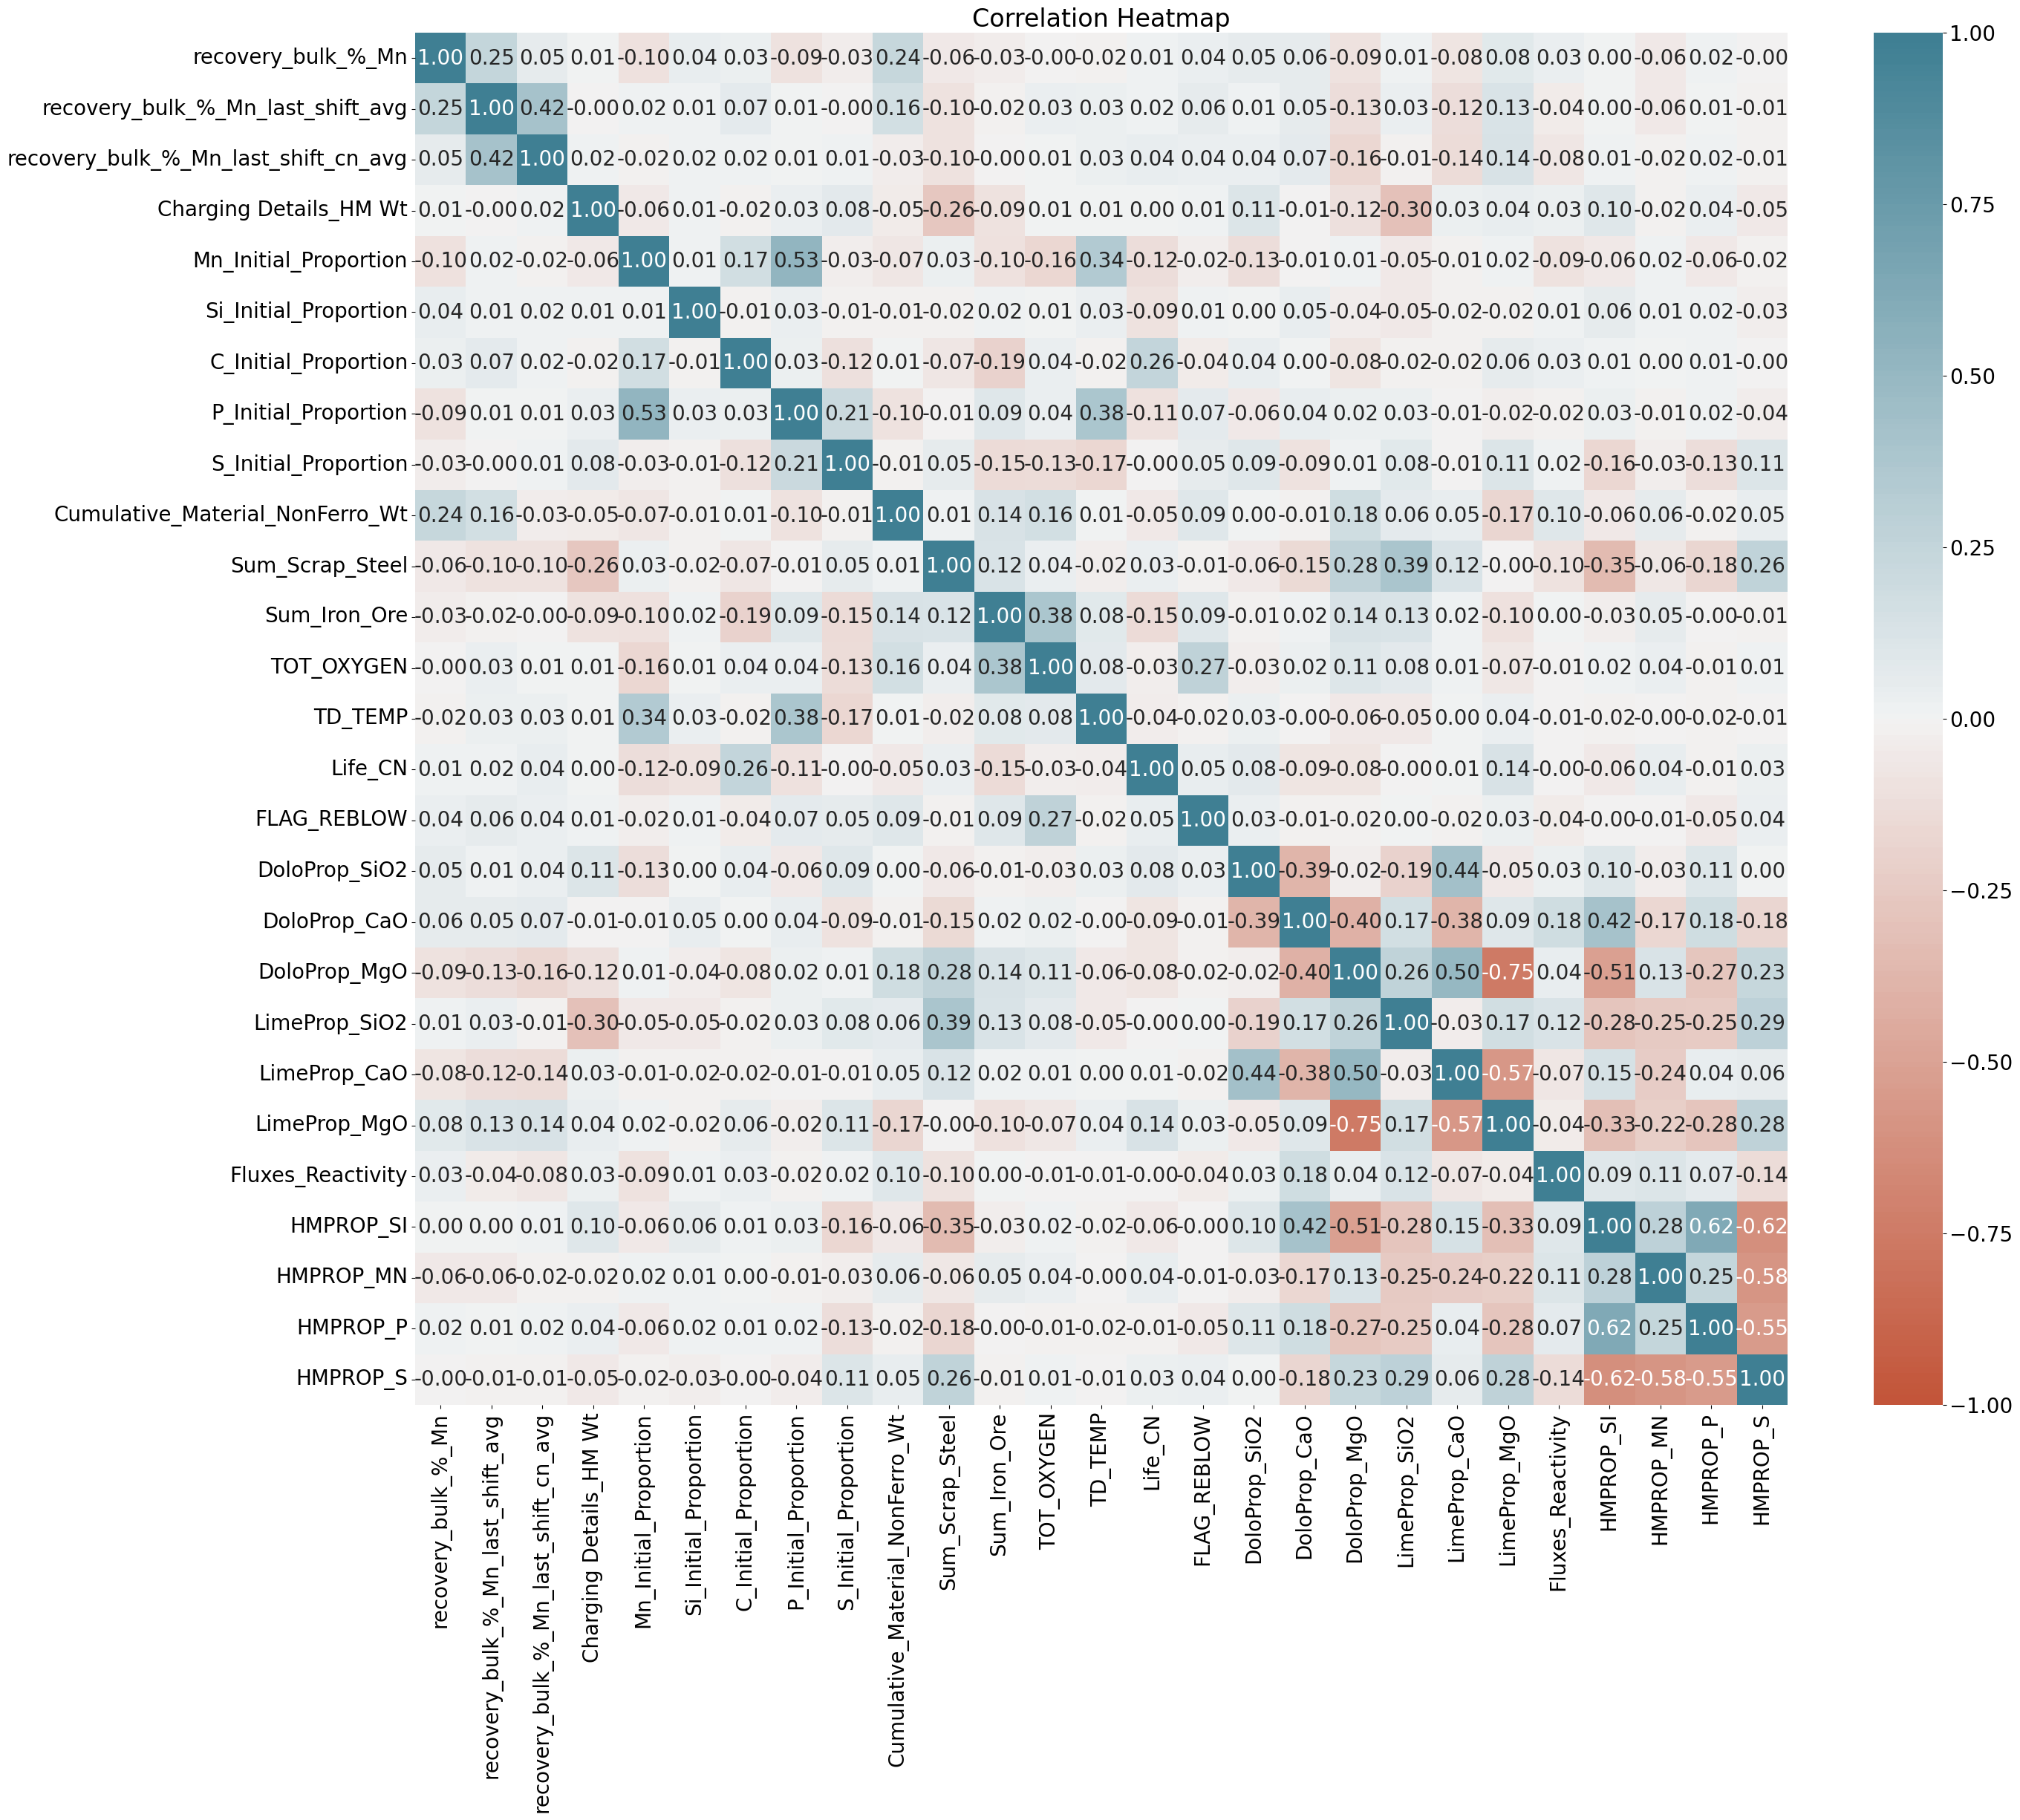

Columns with high Correlation: ['LimeProp_MgO', 'HMPROP_P', 'HMPROP_S']


In [125]:
# Calculate the correlation matrix
corr = df_cleaned[[target] + features].corr()

# Plot the heatmap
plt.figure(figsize=(30, 24))
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200), # Use a diverging color palette
    square=True,
    annot=True,  # Add annotations
    fmt=".2f"    # Format numbers to 2 decimal places
)
plt.title("Correlation Heatmap")
plt.show()

# Identify highly correlated features
corr_matrix = corr.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_hr = [column for column in upper.columns if any(upper[column] > 0.6)]
print("Columns with high Correlation:", to_drop_hr)

In [73]:
df_cleaned.columns.to_list()

['_x',
 'Heat_No',
 'CN',
 'Plan Details_THK',
 'Plan Details_WTH',
 'Plan Details_LTH',
 'Plan Details_CC',
 'Plan Details_Grade',
 'Charging Details_No',
 'Charging Details_L/D',
 'Charging Details_Condition',
 'Charging Details_HM Wt',
 'Charging Details_Time',
 'Charging Details_Ch.Wt',
 'Mixer Analysis_Si',
 'Mixer Analysis_Mn',
 'Mixer Analysis_P',
 'Mixer Analysis_S',
 'Return Heat Details_No',
 'Return Heat Details_T',
 'Return Heat Details_Wt',
 'Tapping_Start',
 'Tapping_End',
 'Tapping_L/D',
 'Tap.Temp_Min',
 'Tap.Temp_Aim',
 'Tap.Temp_Max',
 'Blow Details_Start',
 'Blow Details_End',
 'Blow Details_Oxygen',
 'Bath Details_Temp.',
 'Bath Details_Time',
 'Life_T/Hole',
 'Life_Lance',
 'Life_CN',
 'CREATED BY',
 'HEATNO',
 'REHEAT_NO',
 'BSP_HEATNO',
 'BSP_REHEAT_NO',
 'CONVERTOR_ID',
 'LINING_LIFE',
 'TAPPING_DATE',
 'PROD_DATE',
 'HEAT_YEAR',
 'LANCE',
 'NO_OF_BLOWS',
 'BLOW_START_1',
 'BLOW_END',
 'BLOW_END_1',
 'BLOW_START_2',
 'BLOW_END_2',
 'BLOW_START_3',
 'BLOW_END_3',

In [74]:
df_cleaned.columns.to_list()

['_x',
 'Heat_No',
 'CN',
 'Plan Details_THK',
 'Plan Details_WTH',
 'Plan Details_LTH',
 'Plan Details_CC',
 'Plan Details_Grade',
 'Charging Details_No',
 'Charging Details_L/D',
 'Charging Details_Condition',
 'Charging Details_HM Wt',
 'Charging Details_Time',
 'Charging Details_Ch.Wt',
 'Mixer Analysis_Si',
 'Mixer Analysis_Mn',
 'Mixer Analysis_P',
 'Mixer Analysis_S',
 'Return Heat Details_No',
 'Return Heat Details_T',
 'Return Heat Details_Wt',
 'Tapping_Start',
 'Tapping_End',
 'Tapping_L/D',
 'Tap.Temp_Min',
 'Tap.Temp_Aim',
 'Tap.Temp_Max',
 'Blow Details_Start',
 'Blow Details_End',
 'Blow Details_Oxygen',
 'Bath Details_Temp.',
 'Bath Details_Time',
 'Life_T/Hole',
 'Life_Lance',
 'Life_CN',
 'CREATED BY',
 'HEATNO',
 'REHEAT_NO',
 'BSP_HEATNO',
 'BSP_REHEAT_NO',
 'CONVERTOR_ID',
 'LINING_LIFE',
 'TAPPING_DATE',
 'PROD_DATE',
 'HEAT_YEAR',
 'LANCE',
 'NO_OF_BLOWS',
 'BLOW_START_1',
 'BLOW_END',
 'BLOW_END_1',
 'BLOW_START_2',
 'BLOW_END_2',
 'BLOW_START_3',
 'BLOW_END_3',

In [135]:
df_cleaned[df_cleaned['Charging Details_Time']>'2025-09-01'].shape

(2008, 558)

In [75]:
train_set, test_in_set = train_test_split(df_cleaned[df_cleaned['Charging Details_Time']<'2025-09-01'], test_size=0.2, random_state = 42)
validation_set = df_cleaned[df_cleaned['Charging Details_Time']>='2025-09-01']

In [76]:
train_set.columns.to_list()

['_x',
 'Heat_No',
 'CN',
 'Plan Details_THK',
 'Plan Details_WTH',
 'Plan Details_LTH',
 'Plan Details_CC',
 'Plan Details_Grade',
 'Charging Details_No',
 'Charging Details_L/D',
 'Charging Details_Condition',
 'Charging Details_HM Wt',
 'Charging Details_Time',
 'Charging Details_Ch.Wt',
 'Mixer Analysis_Si',
 'Mixer Analysis_Mn',
 'Mixer Analysis_P',
 'Mixer Analysis_S',
 'Return Heat Details_No',
 'Return Heat Details_T',
 'Return Heat Details_Wt',
 'Tapping_Start',
 'Tapping_End',
 'Tapping_L/D',
 'Tap.Temp_Min',
 'Tap.Temp_Aim',
 'Tap.Temp_Max',
 'Blow Details_Start',
 'Blow Details_End',
 'Blow Details_Oxygen',
 'Bath Details_Temp.',
 'Bath Details_Time',
 'Life_T/Hole',
 'Life_Lance',
 'Life_CN',
 'CREATED BY',
 'HEATNO',
 'REHEAT_NO',
 'BSP_HEATNO',
 'BSP_REHEAT_NO',
 'CONVERTOR_ID',
 'LINING_LIFE',
 'TAPPING_DATE',
 'PROD_DATE',
 'HEAT_YEAR',
 'LANCE',
 'NO_OF_BLOWS',
 'BLOW_START_1',
 'BLOW_END',
 'BLOW_END_1',
 'BLOW_START_2',
 'BLOW_END_2',
 'BLOW_START_3',
 'BLOW_END_3',

In [77]:
train_set = train_set[features + [target, 'Heat_No']].dropna()
train_set.reset_index(drop = True, inplace=True)

test_in_set = test_in_set[features + [target, 'Heat_No']].dropna()
test_in_set.reset_index(drop = True, inplace=True)

validation_set = validation_set[features + [target, 'Heat_No']].dropna()
validation_set.reset_index(drop = True, inplace=True)

In [ ]:
train_set.set_index("Heat_No", inplace=True) # Set 'Heat_No' as the index for train_set 
test_in_set.set_index("Heat_No", inplace=True) # Set 'Heat_No' as the index for test_in_set
validation_set.set_index("Heat_No", inplace=True) 

In [ ]:
x_train = train_set[features] 
y_train = train_set[target]

x_test = test_in_set[features]
y_test = test_in_set[target]

print("Training model on %s rows and testing on %s rows" % (str(x_train.shape[0]), str(x_test.shape[0])))

Training model on 834 rows and testing on 209 rows


In [80]:
# Preprocessing for numerical features only
numeric_features = features

# Define the preprocessor (only StandardScaler for numerical features)
preprocessor = StandardScaler()

# # Define the Random Forest Regressor
# rf = RandomForestRegressor(random_state=42)

# # Define the parameter grid for hyperparameter tuning
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
# }


xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'reg_alpha': [0, 0.1, 1],   # L1 regularization
#     'reg_lambda': [1, 1.5, 2],  # L2 regularization
# }

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2],
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',
    n_jobs=-1,
    cv=5,
    verbose=2,
    refit=True
)

# Fit the model to the training data
grid_search.fit(x_train, y_train)

# Get the best model
model = grid_search.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


## Model Metrics

In [81]:
# Make predictions on the training and test sets
train_set_predictions = train_set.copy()
train_set_predictions['prediction'] = model.predict(x_train)

test_set_predictions = test_in_set.copy()
test_set_predictions['prediction'] = model.predict(x_test)

validation_set_predictions = validation_set.copy()
validation_set_predictions['prediction'] = model.predict(validation_set[features])

# Calculate metrics for the training set
train_r2 = r2_score(y_train, train_set_predictions['prediction'])
train_rmse = np.sqrt(mean_squared_error(y_train, train_set_predictions['prediction']))
train_mape = np.mean(np.abs((y_train - train_set_predictions['prediction']) / y_train)) * 100

# Calculate metrics for the test set
test_r2 = r2_score(y_test, test_set_predictions['prediction'])
test_rmse = np.sqrt(mean_squared_error(y_test, test_set_predictions['prediction']))
test_mape = np.mean(np.abs((y_test - test_set_predictions['prediction']) / y_test)) * 100

# Calculate metrics for the validation set
validation_r2 = r2_score(validation_set[target], validation_set_predictions['prediction'])
validation_rmse = np.sqrt(mean_squared_error(validation_set[target], validation_set_predictions['prediction']))
validation_mape = np.mean(np.abs((validation_set[target] - validation_set_predictions['prediction']) / validation_set[target])) * 100

# Print the metrics
print("Training Metrics:")
print(f"R-squared: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAPE: {train_mape:.2f}%")

print("\nTest Metrics:")
print(f"R-squared: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAPE: {test_mape:.2f}%")

print("\nValidation Metrics:")
print(f"R-squared: {validation_r2:.4f}")
print(f"RMSE: {validation_rmse:.4f}")
print(f"MAPE: {validation_mape:.2f}%")

Training Metrics:
R-squared: 0.4132
RMSE: 5.0842
MAPE: 4.62%

Test Metrics:
R-squared: 0.1235
RMSE: 6.1591
MAPE: 5.55%

Validation Metrics:
R-squared: 0.0617
RMSE: 6.7459
MAPE: 5.82%


In [138]:
import plotly.graph_objects as go

# Select the first 200 heats from the validation set
first_200_actual = validation_set[target].iloc[:100]
first_200_predicted = validation_set_predictions['prediction'].iloc[:100]

# Create the line chart
fig = go.Figure()

# Add the actual values to the plot
fig.add_trace(go.Scatter(
    x=first_200_actual.index,
    y=first_200_actual,
    mode='lines+markers',
    name='Actual',
    line=dict(color='blue'),
    marker=dict(size=5)
))

# Add the predicted values to the plot
fig.add_trace(go.Scatter(
    x=first_200_predicted.index,
    y=first_200_predicted,
    mode='lines+markers',
    name='Predicted',
    line=dict(color='red'),
    marker=dict(size=5)
))

# Customize the layout
fig.update_layout(
    title="Bulk Mn Recovery % - Actual vs Predicted Values",
    xaxis_title="Heat Index",
    yaxis_title="Target Value",
    legend=dict(title="Legend"),
    width=825,  # Adjust the width of the plot
    # height=600,  # Adjust the height of the plot
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgray"),
    yaxis=dict(showgrid=True, gridcolor="lightgray")
)

# Show the plot
fig.show()

# SHAP

Background dataset has 834 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=834 when initializing the masker.
Computing SHAP values: 100%|██████████| 14/14 [00:00<00:00, 51554.22it/s]


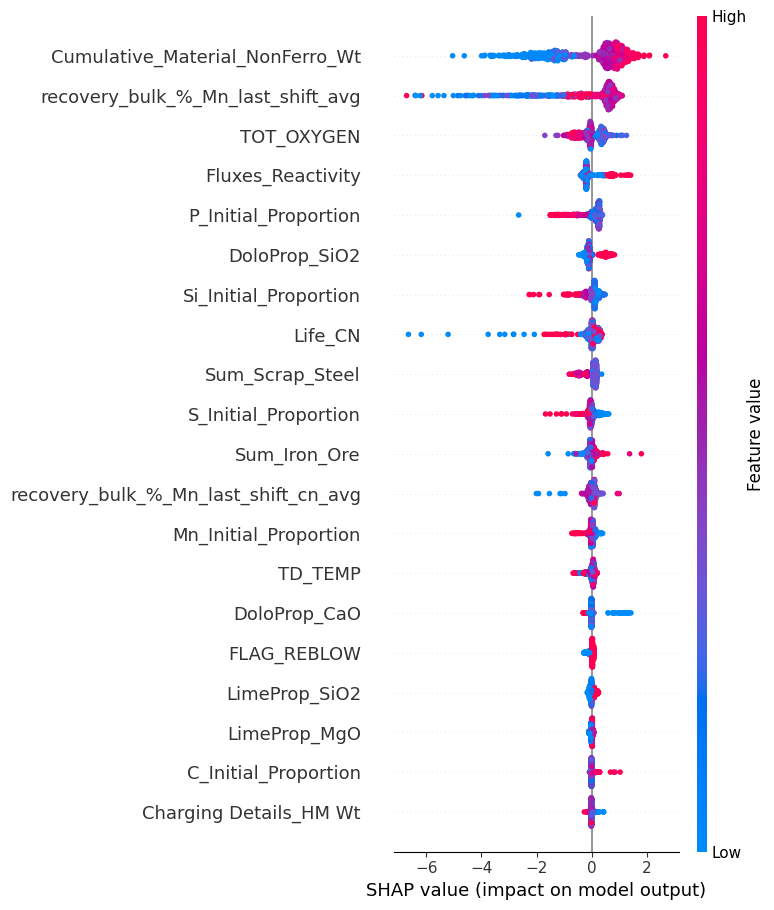

CPU times: total: 2.45 s
Wall time: 2min 44s


In [139]:
%%time
import joblib
import shap
explainer = shap.Explainer(model.predict, x_train)

# Define a function to compute SHAP values for a subset of the data
def compute_shap_values(subset):
    return explainer(subset)

# Split the data into smaller chunks for parallel processing
n_jobs = 14  # Use all available cores
chunks = np.array_split(x_train, n_jobs)

# Create a parallel backend with a progress bar
parallel = joblib.Parallel(n_jobs=n_jobs, backend='loky')
tasks = (joblib.delayed(compute_shap_values)(chunk) for chunk in chunks)

# Compute SHAP values in parallel with a progress bar
shap_values_chunks = list(tqdm(parallel(tasks), total=len(chunks), desc="Computing SHAP values"))

# Concatenate the results
shap_values = np.concatenate([shap_values.values for shap_values in shap_values_chunks])

shap.summary_plot(shap_values, x_train)

## Summary

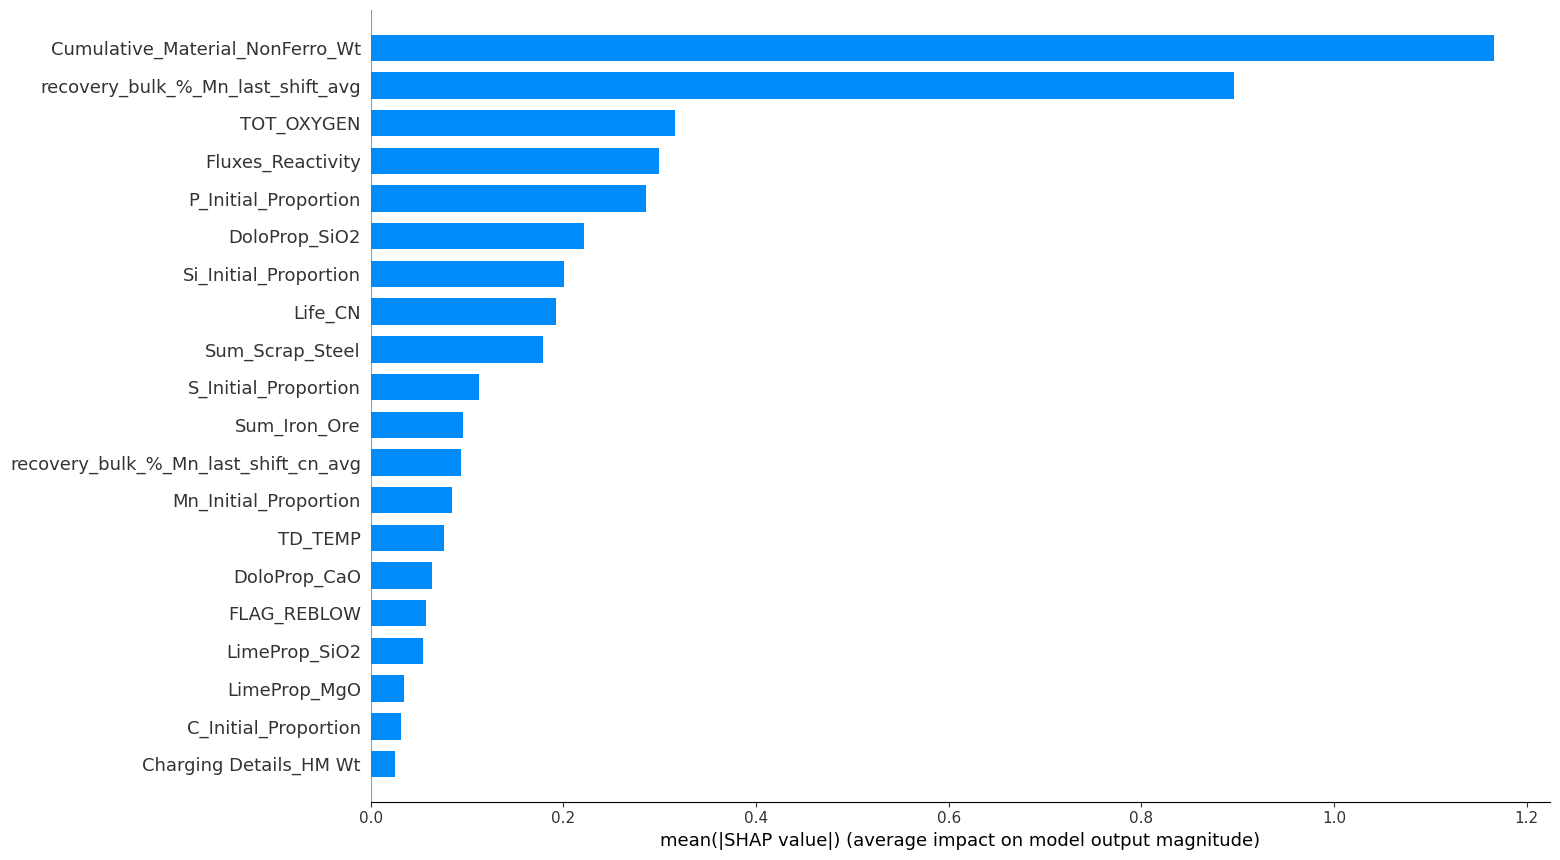

In [85]:
plt.close("all")
plt.rcParams.update({"font.size": 20})
fig = plt.figure(figsize=(16, 9))

shap.summary_plot(
    shap_values,
    train_set_predictions[model.feature_names_in_],
    plot_type='bar',
    show=True,
    plot_size=(16, 9),
)

In [86]:
# Calculate mean absolute SHAP values for each feature
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)

# Retrieve the feature names
feature_names = model.feature_names_in_

# Combine feature names and their importances
feature_importance = list(zip(feature_names, mean_abs_shap_values))

# Sort the features based on their importance in descending order
sorted_feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

# Extract the sorted list of feature names
sorted_feature_names = [feature for feature, importance in sorted_feature_importance]

# Print or use the sorted list of feature names as needed
print(sorted_feature_names)

[np.str_('Cumulative_Material_NonFerro_Wt'), np.str_('recovery_bulk_%_Mn_last_shift_avg'), np.str_('TOT_OXYGEN'), np.str_('Fluxes_Reactivity'), np.str_('P_Initial_Proportion'), np.str_('DoloProp_SiO2'), np.str_('Si_Initial_Proportion'), np.str_('Life_CN'), np.str_('Sum_Scrap_Steel'), np.str_('S_Initial_Proportion'), np.str_('Sum_Iron_Ore'), np.str_('recovery_bulk_%_Mn_last_shift_cn_avg'), np.str_('Mn_Initial_Proportion'), np.str_('TD_TEMP'), np.str_('DoloProp_CaO'), np.str_('FLAG_REBLOW'), np.str_('LimeProp_SiO2'), np.str_('LimeProp_MgO'), np.str_('C_Initial_Proportion'), np.str_('Charging Details_HM Wt'), np.str_('LimeProp_CaO'), np.str_('DoloProp_MgO'), np.str_('HMPROP_SI'), np.str_('HMPROP_MN'), np.str_('HMPROP_P'), np.str_('HMPROP_S')]


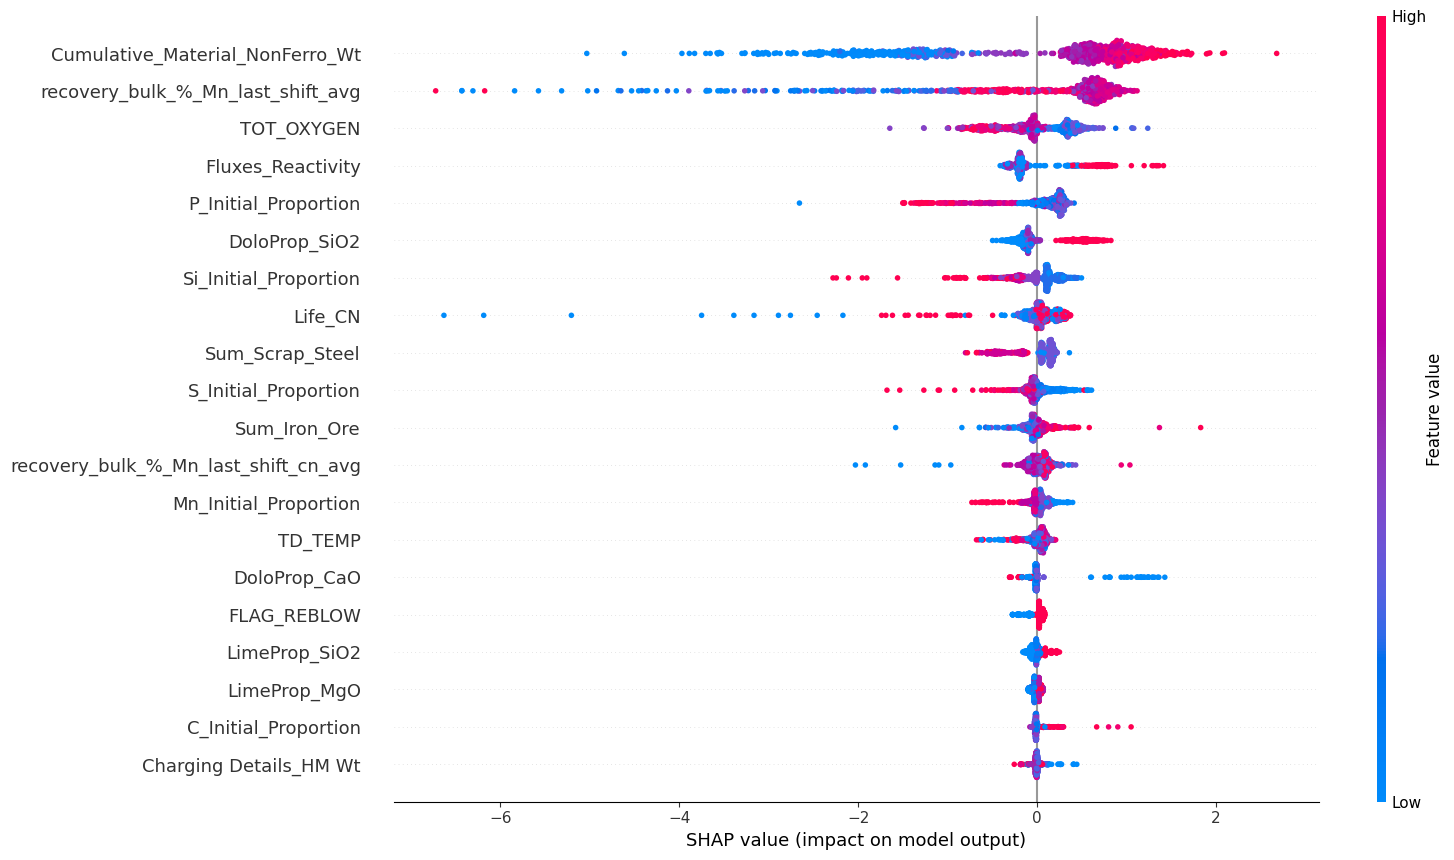

In [87]:
plt.close("all")
# plt.rcParams.update({"font.size": 20})
fig = plt.figure(figsize=(16, 9))

shap.summary_plot(
    shap_values,
    train_set_predictions[model.feature_names_in_],
    plot_type='dot',
#     feature_names=[td[f]["name"] for f in model.features_in],
    show=True,
    plot_size=(16, 9),
)

## Dependence plots

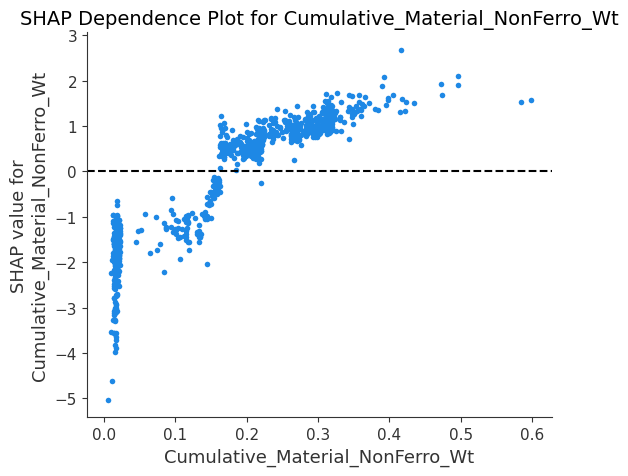

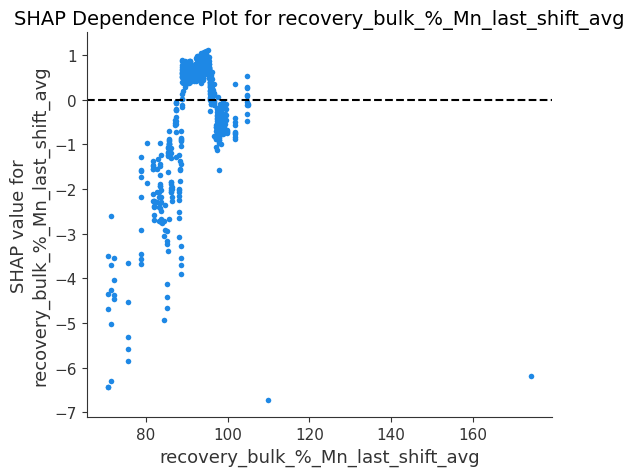

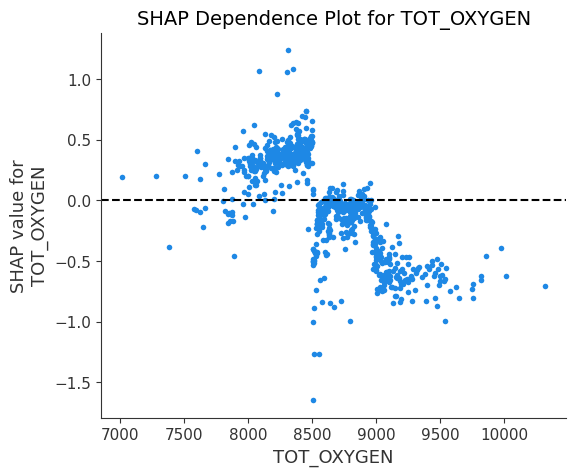

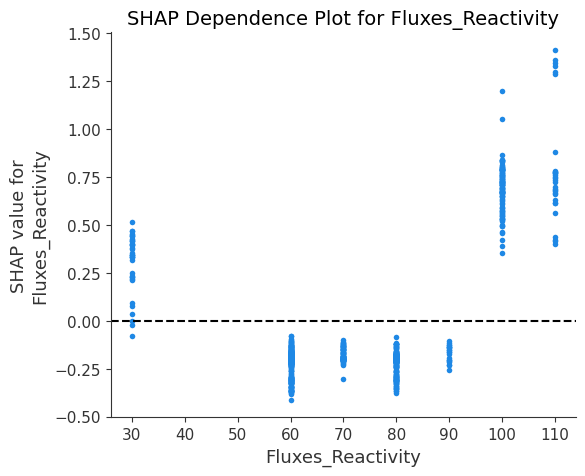

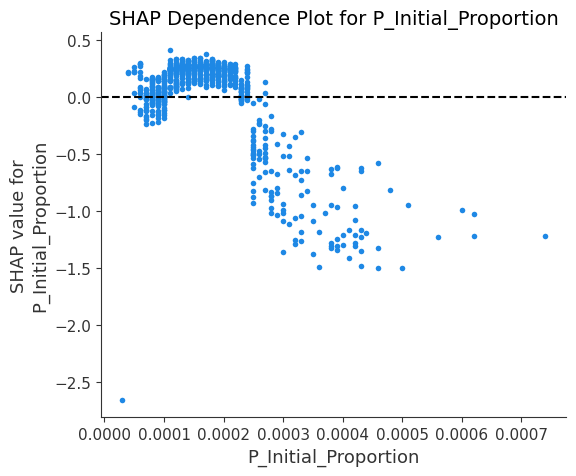

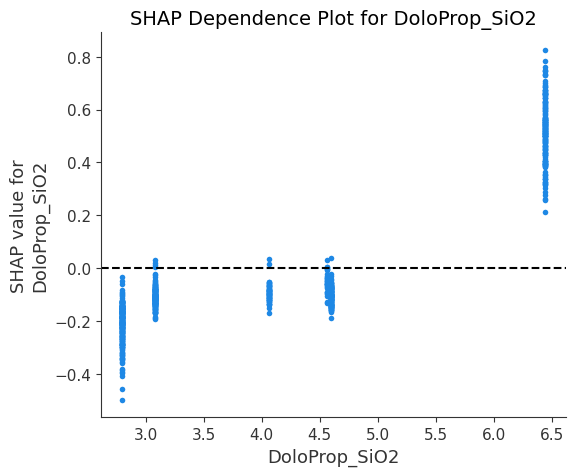

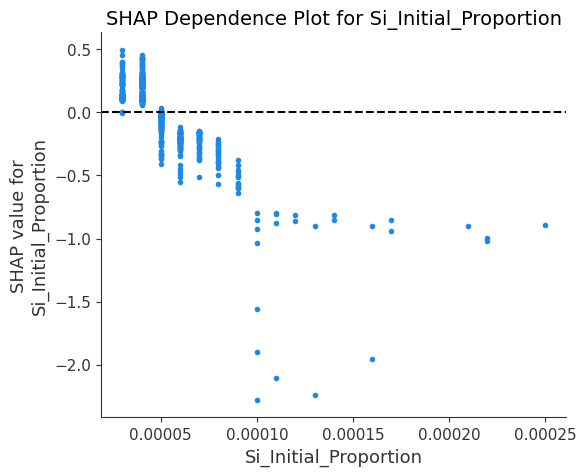

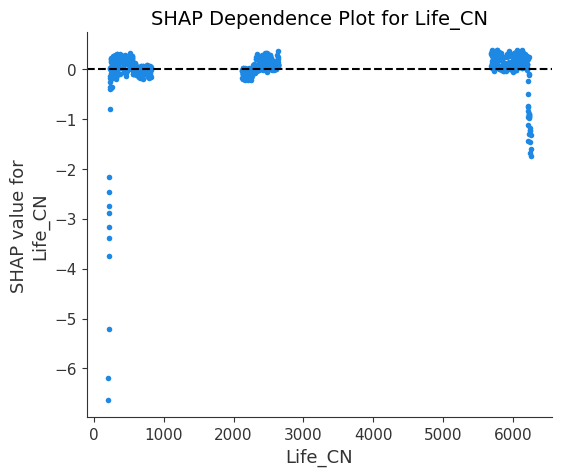

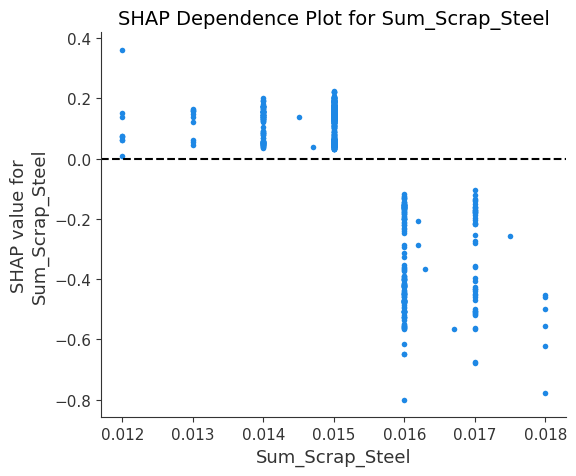

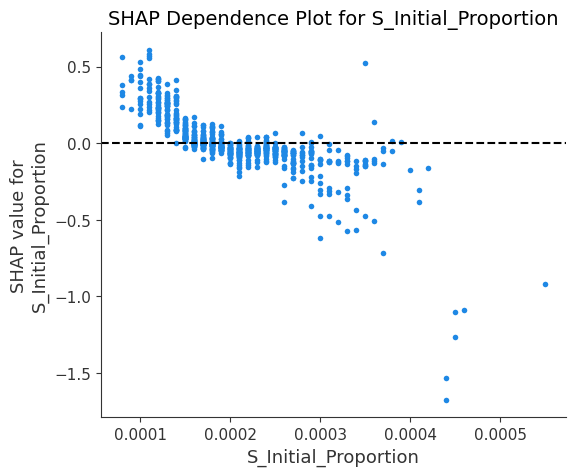

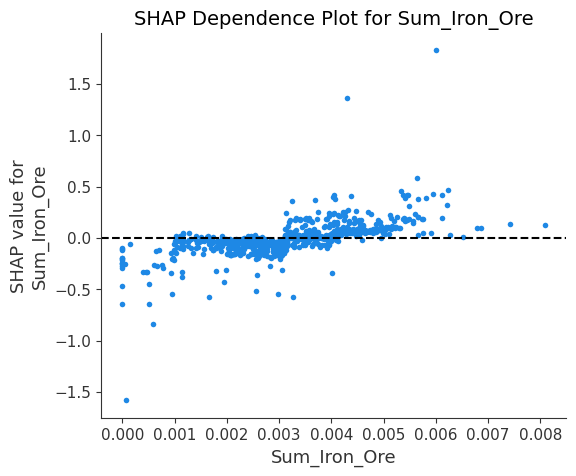

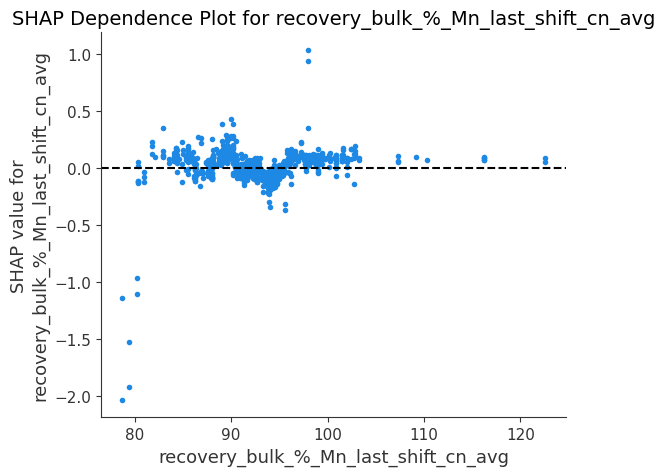

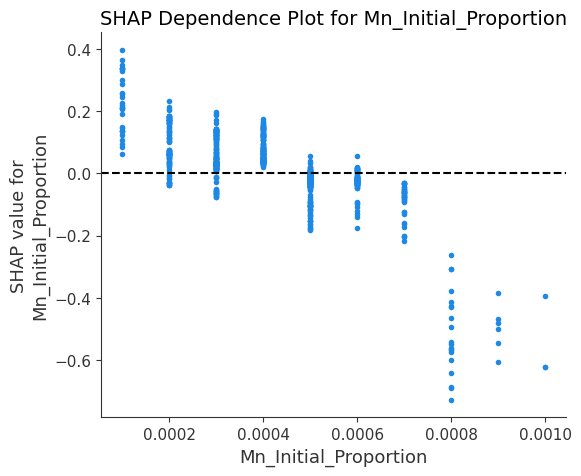

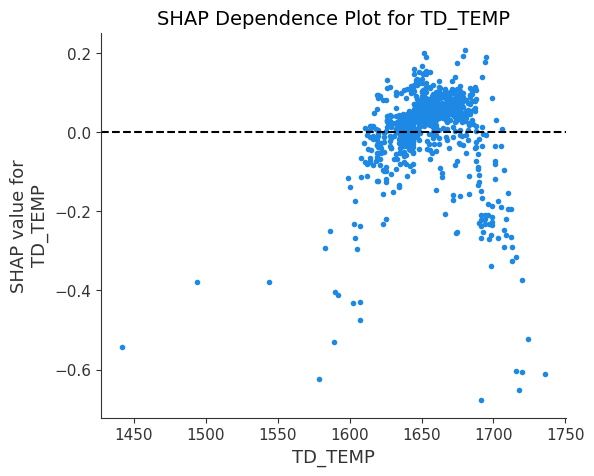

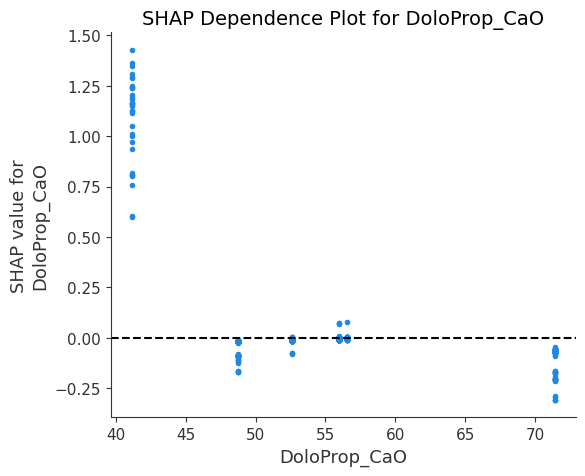

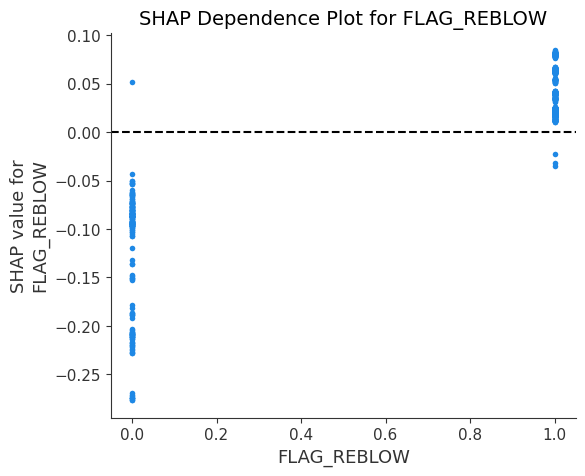

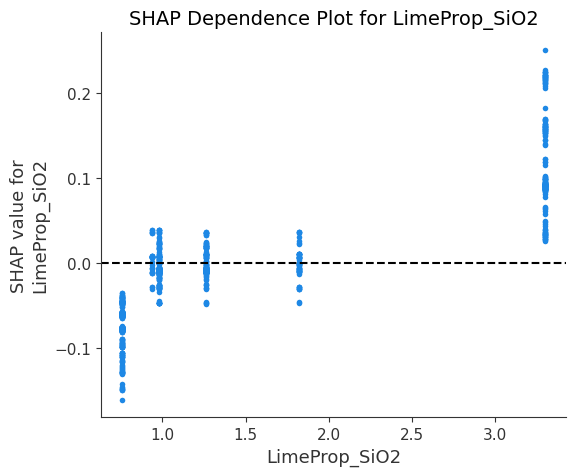

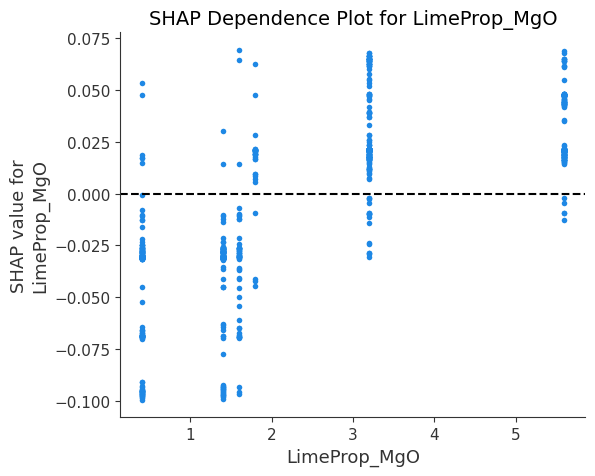

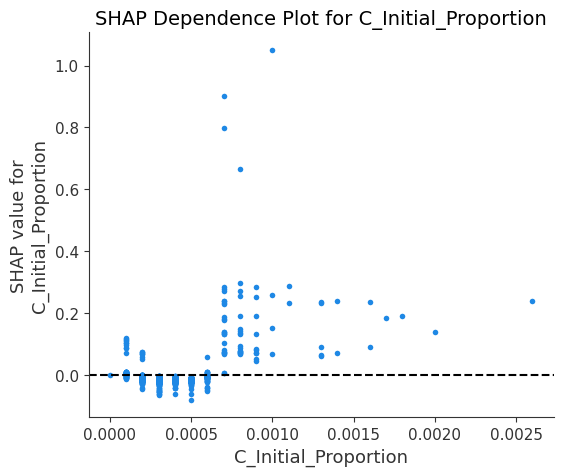

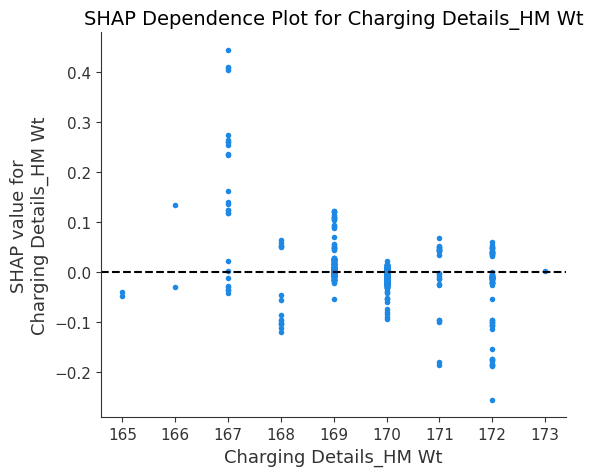

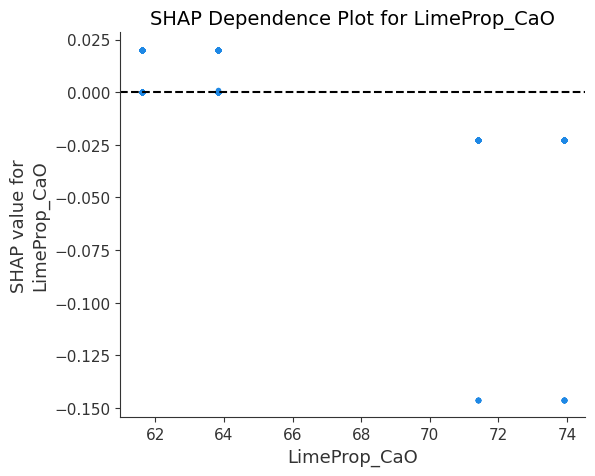

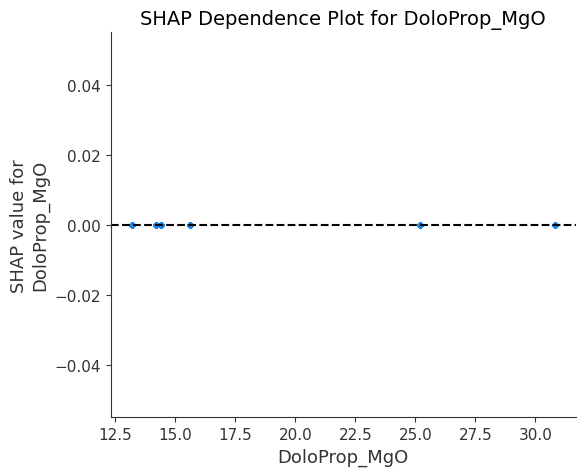

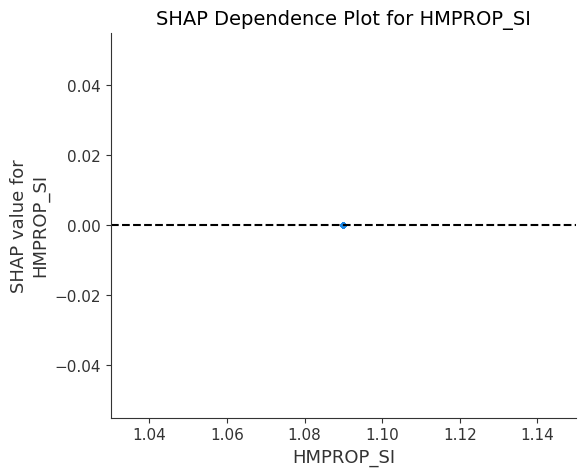

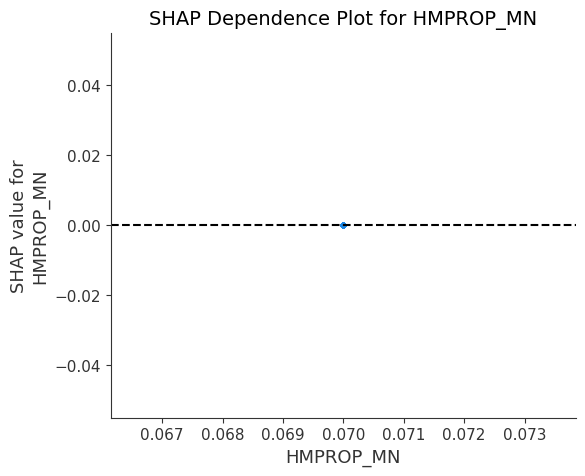

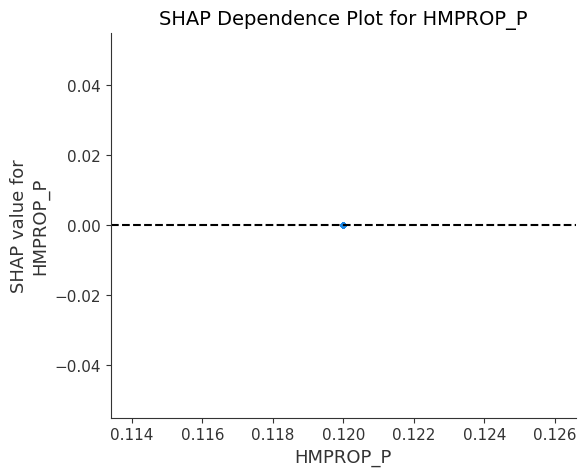

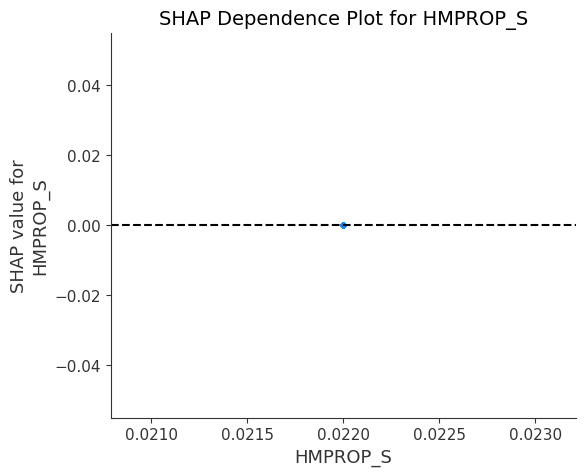

In [88]:
for feature in sorted_feature_names:
    shap.dependence_plot(
        feature,
        shap_values,
        x_train[model.feature_names_in_],
        interaction_index=None,
        show=False  # Set show to False to customize the plot before displaying
    )
    plt.axhline(y=0, color='k', linestyle='--')  # Add a horizontal line at y=0
    plt.title(f"SHAP Dependence Plot for {feature}", fontsize=14)  # Optionally add a title
    plt.show()  # Display the plot

In [89]:
joblib.dump(model, "MnBulkRecoveryModel_20251210.pkl")

['MnBulkRecoveryModel_20251210.pkl']